# 장애인콜택시 대기시간 예측 모델링 - RandomForest

이 노트북은 VSCode에서 현재 프로젝트 폴더 기준으로 전처리 CSV를 불러와 `접수→승차 대기시간`을 예측하는 RandomForest 모델링 노트북이다.

## 목적

- 프로젝트 폴더의 `data/processed`에서 전처리 CSV 불러오기
- 임차택시 바로콜 / 특장차 바로콜 승차완료 데이터 생성
- 예측 대상 `target_min = 접수→승차 대기시간` 생성
- 130분 이후 장시간 대기와 02~06시 새벽 호출을 별도관리 구간으로 분리
- 기존과 동일하게 train / validation / test 분리
- RandomForestRegressor 기반 모델 학습 및 평가

## 모델링 기준

전체 데이터는 보존하되, 일반 패턴 모델에서는 아래 조건을 제외한 버전으로 학습한다.

```text
1. 접수→승차 대기시간 130분 초과
2. 접수시간 02~06시
3. 위 두 조건이 겹치는 데이터
```

주의: RandomForestRegressor는 scikit-learn 모델이므로 GPU를 직접 사용하지 않는다. 학습은 CPU 병렬 처리(`n_jobs=-1`)로 수행한다.

## 1. 라이브러리 및 로컬 프로젝트 경로 설정

VSCode에서 이 노트북을 실행할 때는 Google Drive 경로를 사용하지 않는다.

현재 프로젝트 구조를 기준으로 아래 CSV를 불러온다.

```text
data/processed/임차택시_대기시간_전처리.csv
data/processed/특장차_대기시간_전처리_접수유형분류.csv
```

노트북 실행 위치가 프로젝트 루트이든 `notebooks_waiting_time` 폴더이든 자동으로 프로젝트 루트를 찾도록 설정한다.

In [4]:
from pathlib import Path
import unicodedata
import platform

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


# 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False


In [5]:
# =========================
# 로컬 프로젝트 경로 설정
# =========================

RENTAL_FILENAME = "임차택시_대기시간_전처리.csv"
SPECIAL_FILENAME = "특장차_대기시간_전처리_접수유형분류.csv"


def normalize_text(text):
    return unicodedata.normalize("NFC", str(text))


def find_project_root(start_path=None):
    """
    현재 실행 위치에서 위로 올라가며 data/processed 폴더가 있는 프로젝트 루트를 찾는다.
    """
    start = Path.cwd() if start_path is None else Path(start_path)
    candidates = [start] + list(start.parents)

    for candidate in candidates:
        if (candidate / "data" / "processed").exists():
            return candidate

    raise FileNotFoundError(
        "data/processed 폴더를 찾을 수 없습니다. "
        "VSCode의 현재 작업 폴더가 calltaxi-DA 프로젝트 안인지 확인하세요."
    )


def find_csv_in_processed(processed_dir, filename):
    """
    1순위: data/processed/{filename}
    2순위: 한글 자모 정규화 차이를 고려해 processed 폴더의 CSV 전체에서 파일명 비교
    """
    direct_path = processed_dir / filename

    if direct_path.exists():
        return direct_path

    target_name = normalize_text(filename)
    matches = [
        path
        for path in processed_dir.rglob("*.csv")
        if normalize_text(path.name) == target_name
    ]

    if len(matches) == 0:
        print("processed 폴더에서 찾은 CSV 파일:")
        for path in sorted(processed_dir.rglob("*.csv")):
            print(" -", path)
        raise FileNotFoundError(
            f"{filename} 파일을 찾을 수 없습니다. "
            f"{processed_dir} 안의 파일명을 확인하세요."
        )

    if len(matches) > 1:
        print(f"{filename} 후보가 여러 개입니다. 첫 번째 파일을 사용합니다.")
        for path in matches:
            print(" -", path)

    return matches[0]


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "processed"

RENTAL_PATH = find_csv_in_processed(DATA_DIR, RENTAL_FILENAME)
SPECIAL_PATH = find_csv_in_processed(DATA_DIR, SPECIAL_FILENAME)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("RENTAL_PATH:", RENTAL_PATH)
print("SPECIAL_PATH:", SPECIAL_PATH)
print("RENTAL exists:", RENTAL_PATH.exists())
print("SPECIAL exists:", SPECIAL_PATH.exists())

PROJECT_ROOT: /Users/blaumonde/calltaxi-DA
DATA_DIR: /Users/blaumonde/calltaxi-DA/data/processed
RENTAL_PATH: /Users/blaumonde/calltaxi-DA/data/processed/임차택시_대기시간_전처리.csv
SPECIAL_PATH: /Users/blaumonde/calltaxi-DA/data/processed/특장차_대기시간_전처리_접수유형분류.csv
RENTAL exists: True
SPECIAL exists: True


## 2. 데이터 로드

모델링 대상은 기존과 동일하게 바로콜 승차완료 데이터만 사용한다.

- 임차택시: `임차택시_바로콜여부 == True`, `대기시간분석_포함여부 == True`
- 특장차: `특장차_바로콜_후보여부 == True` 또는 `특장차_접수유형_후보_최종 == "바로콜 후보"`

In [6]:
SEOUL_GU = {
    "강남구", "강동구", "강북구", "강서구", "관악구",
    "광진구", "구로구", "금천구", "노원구", "도봉구",
    "동대문구", "동작구", "마포구", "서대문구", "서초구",
    "성동구", "성북구", "송파구", "양천구", "영등포구",
    "용산구", "은평구", "종로구", "중구", "중랑구",
}


def existing_cols(path, wanted_cols):
    header = pd.read_csv(path, nrows=0).columns.tolist()
    return [col for col in wanted_cols if col in header]


def classify_move_type(row):
    origin = row.get("출발구")
    dest = row.get("목적구")

    origin_in_seoul = origin in SEOUL_GU
    dest_in_seoul = dest in SEOUL_GU

    if origin_in_seoul and dest_in_seoul:
        if origin == dest:
            return "구 내 이동"
        return "구 간 이동"

    if origin_in_seoul and not dest_in_seoul:
        return "서울→서울 외"

    if not origin_in_seoul and dest_in_seoul:
        return "서울 외→서울"

    return "서울 외↔서울 외"


def load_modeling_dataset():
    common_cols = [
        "접수일시", "예정일시", "배차일시", "승차일시", "하차일시", "취소일시",
        "출발구", "출발동", "목적구", "목적동",
        "이용목적", "요금", "승차거리", "차량구분", "장애유형",
        "접수_배차_분", "배차_승차_분", "접수_승차_분",
        "접수_취소_분", "배차_취소_분", "접수승차_날짜차이",
    ]

    rental_cols = common_cols + [
        "예약목적여부",
        "임차택시_바로콜여부",
        "임차택시_장시간예외여부",
        "임차택시_예약성예외여부",
        "임차택시_취소분석유형",
        "대기시간분석_포함여부",
        "대기시간분석_제외사유",
    ]

    special_cols = common_cols + [
        "접수시간대", "접수시간대_HH", "접수요일", "평일주말",
        "세부이동유형", "승차거리_km", "승차거리구간",
        "특장차_접수유형", "특장차_접수유형_분류상태", "특장차_접수유형_메모",
        "접수일자", "예정일자", "취소일자", "접수시", "예정시", "예정시간",
        "취소_접수유형_후보", "_원자료_index",
        "특장차_탑승완료_필수일시존재여부",
        "특장차_탑승완료_시간논리정상여부",
        "심야시간사전예약_후보여부",
        "전일접수_후보여부",
        "특장차_바로콜_후보여부",
        "특장차_접수유형_후보_보완",
        "정기접수_목적후보여부",
        "정기접수_가능패턴여부",
        "동일패턴건수_보완",
        "예정_배차_분", "예정_승차_분",
        "특장차_접수유형_후보_최종",
    ]

    rental = pd.read_csv(
        RENTAL_PATH,
        usecols=existing_cols(RENTAL_PATH, rental_cols),
        low_memory=False,
    )

    special = pd.read_csv(
        SPECIAL_PATH,
        usecols=existing_cols(SPECIAL_PATH, special_cols),
        low_memory=False,
    )

    print("임차택시 원본 shape:", rental.shape)
    print("특장차 원본 shape:", special.shape)

    # datetime 변환
    for frame in [rental, special]:
        for col in [
            "접수일시", "예정일시", "배차일시", "승차일시", "하차일시", "취소일시",
            "접수일자", "예정일자", "취소일자",
        ]:
            if col in frame.columns:
                frame[col] = pd.to_datetime(frame[col], errors="coerce")

    # 임차택시 바로콜 승차완료
    rental_model = rental[
        rental["접수일시"].notna()
        & rental["승차일시"].notna()
        & rental["임차택시_바로콜여부"].fillna(False).astype(bool)
        & rental["대기시간분석_포함여부"].fillna(False).astype(bool)
    ].copy()

    rental_model["model_group"] = "임차택시_바로콜"

    # 특장차 바로콜 승차완료
    special_model = special[
        special["접수일시"].notna()
        & special["승차일시"].notna()
        & (
            special["특장차_바로콜_후보여부"].fillna(False).astype(bool)
            | special["특장차_접수유형_후보_최종"].eq("바로콜 후보")
        )
    ].copy()

    special_model["model_group"] = "특장차_바로콜"

    print("임차택시 바로콜 승차완료:", rental_model.shape)
    print("특장차 바로콜 승차완료:", special_model.shape)

    # 컬럼 맞춰서 결합
    all_cols = sorted(set(rental_model.columns) | set(special_model.columns))

    data = pd.concat(
        [
            rental_model.reindex(columns=all_cols),
            special_model.reindex(columns=all_cols),
        ],
        ignore_index=True,
    )

    # numeric 변환
    numeric_cols = [
        "요금", "승차거리", "승차거리_km",
        "접수_배차_분", "배차_승차_분", "접수_승차_분",
        "접수_취소_분", "배차_취소_분", "접수승차_날짜차이",
        "접수시간대_HH", "접수시", "예정시",
        "예정_배차_분", "예정_승차_분", "동일패턴건수_보완",
    ]

    for col in numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    # target 생성
    data = data[
        data["접수일시"].notna()
        & data["승차일시"].notna()
        & data["접수_승차_분"].notna()
        & data["접수_승차_분"].ge(0)
    ].copy()

    data["target_min"] = data["접수_승차_분"]

    # 시간 변수
    data["hour"] = data["접수일시"].dt.hour.astype("int16")
    data["dayofweek"] = data["접수일시"].dt.dayofweek.astype("int16")
    data["month"] = data["접수일시"].dt.month.astype("int16")

    data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype("int8")
    data["is_night"] = data["hour"].between(0, 6, inclusive="both").astype("int8")
    data["is_dawn_02_06"] = data["hour"].between(2, 6, inclusive="both").astype("int8")
    data["is_commute"] = (
        data["hour"].between(7, 9, inclusive="both")
        | data["hour"].between(17, 19, inclusive="both")
    ).astype("int8")

    # 승차거리_km 통일
    if "승차거리_km" not in data.columns:
        data["승차거리_km"] = np.nan

    if "승차거리" in data.columns:
        data["승차거리_km"] = data["승차거리_km"].fillna(
            pd.to_numeric(data["승차거리"], errors="coerce")
        )

    # 세부이동유형 보완
    computed_move_type = data.apply(classify_move_type, axis=1)

    if "세부이동유형" in data.columns:
        data["세부이동유형"] = data["세부이동유형"].fillna(computed_move_type)
        data.loc[data["세부이동유형"].astype(str).eq(""), "세부이동유형"] = computed_move_type
    else:
        data["세부이동유형"] = computed_move_type

    # 문자열 결측 처리
    object_cols = data.select_dtypes(include="object").columns

    for col in object_cols:
        data[col] = data[col].fillna("미상").astype(str)

    data = data.sort_values("접수일시").reset_index(drop=True)

    return data

## 3. 데이터 로드 실행

In [7]:
data = load_modeling_dataset()

print("최종 data shape:", data.shape)
display(data.head())

임차택시 원본 shape: (328875, 28)
특장차 원본 shape: (1393534, 51)
임차택시 바로콜 승차완료: (305729, 29)
특장차 바로콜 승차완료: (1099084, 52)


/var/folders/br/x7f7fw1907z6wpb38fpn1kpm0000gn/T/ipykernel_33530/3787358709.py:189: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = data.select_dtypes(include="object").columns


최종 data shape: (1404813, 67)


,_원자료_index,model_group,대기시간분석_제외사유,대기시간분석_포함여부,동일패턴건수_보완,목적구,목적동,배차_승차_분,배차_취소_분,배차일시,세부이동유형,승차거리,승차거리_km,승차거리구간,승차일시,심야시간사전예약_후보여부,예약목적여부,예정_배차_분,예정_승차_분,예정시,예정시간,예정일시,예정일자,요금,이용목적,임차택시_바로콜여부,임차택시_예약성예외여부,임차택시_장시간예외여부,임차택시_취소분석유형,장애유형,전일접수_후보여부,접수_배차_분,접수_승차_분,접수_취소_분,접수승차_날짜차이,접수시,접수시간대,접수시간대_HH,접수요일,접수일시,접수일자,정기접수_가능패턴여부,정기접수_목적후보여부,차량구분,출발구,출발동,취소_접수유형_후보,취소일시,취소일자,특장차_바로콜_후보여부,특장차_접수유형,특장차_접수유형_메모,특장차_접수유형_분류상태,특장차_접수유형_후보_보완,특장차_접수유형_후보_최종,특장차_탑승완료_시간논리정상여부,특장차_탑승완료_필수일시존재여부,평일주말,하차일시,target_min,hour,dayofweek,month,is_weekend,is_night,is_dawn_02_06,is_commute
0,0.0,특장차_바로콜,미상,미상,0.0,강북구,수유제2동,22.361000,NaN,2025-01-01 00:27:31.307,구 간 이동,17667,17.667,15~25km,2025-01-01 00:49:52.967,False,미상,26.086333,48.447333,0.0,00:01:26,2025-01-01 00:01:26.127,2025-01-01 00:00:00,3400.0,기타,미상,미상,미상,미상,지체,False,26.086333,48.447333,NaN,0.0,0.0,00:00:00,0.0,수,2025-01-01 00:01:26.127,2025-01-01 00:00:00,False,False,특장차,용산구,남영동,취소 아님,NaT,미상,True,NaN,NaN,미분류,바로콜 후보,바로콜 후보,True,True,평일,2025-01-01 01:35:06.747,48.447333,0,2,1,0,1,0,0
1,2.0,특장차_바로콜,미상,미상,0.0,노원구,하계1동,16.608883,NaN,2025-01-01 00:19:41.900,구 내 이동,2910,2.910,0.5~3km,2025-01-01 00:36:18.433,False,미상,15.698333,32.307217,0.0,00:04:00,2025-01-01 00:04:00.000,2025-01-01 00:00:00,1500.0,기타,미상,미상,미상,미상,뇌병,False,16.177833,32.786717,NaN,0.0,0.0,00:00:00,0.0,수,2025-01-01 00:03:31.230,2025-01-01 00:00:00,False,False,특장차,노원구,상계5동,취소 아님,NaT,미상,True,NaN,NaN,미분류,바로콜 후보,바로콜 후보,True,True,평일,2025-01-01 00:49:45.857,32.786717,0,2,1,0,1,0,0
2,3.0,특장차_바로콜,미상,미상,0.0,중구,명동,20.113167,NaN,2025-01-01 00:33:41.650,구 간 이동,10421,10.421,10~15km,2025-01-01 00:53:48.440,False,미상,29.694167,49.807333,0.0,00:04:00,2025-01-01 00:04:00.000,2025-01-01 00:00:00,2900.0,기타,미상,미상,미상,미상,지체,False,30.017950,50.131117,NaN,0.0,0.0,00:00:00,0.0,수,2025-01-01 00:03:40.573,2025-01-01 00:00:00,False,False,특장차,영등포구,당산제1동,취소 아님,NaT,미상,True,NaN,NaN,미분류,바로콜 후보,바로콜 후보,True,True,평일,2025-01-01 01:33:38.120,50.131117,0,2,1,0,1,0,0
3,4.0,특장차_바로콜,미상,미상,0.0,서초구,내곡동,33.567500,NaN,2025-01-01 00:06:33.790,구 간 이동,11943,11.943,10~15km,2025-01-01 00:40:07.840,False,미상,2.311883,35.879383,0.0,00:04:15,2025-01-01 00:04:15.077,2025-01-01 00:00:00,3000.0,기타,미상,미상,미상,미상,지체,False,2.311883,35.879383,NaN,0.0,0.0,00:00:00,0.0,수,2025-01-01 00:04:15.077,2025-01-01 00:00:00,False,False,특장차,송파구,오금동,취소 아님,NaT,미상,True,NaN,NaN,미분류,바로콜 후보,바로콜 후보,True,True,평일,2025-01-01 01:10:15.110,35.879383,0,2,1,0,1,0,0
4,5.0,특장차_바로콜,미상,미상,1.0,서초구,반포2동,38.008050,NaN,2025-01-01 00:16:19.457,구 내 이동,5205,5.205,5~10km,2025-01-01 00:54:19.940,False,미상,10.324283,48.332333,0.0,00:06:00,2025-01-01 00:06:00.000,2025-01-01 00:00:00,1700.0,귀가,미상,미상,미상,미상,뇌병,False,10.424283,48.432333,NaN,0.0,0.0,00:00:00,0.0,수,2025-01-01 00:05:54.000,2025-01-01 00:00:00,False,True,특장차,서초구,서초3동,취소 아님,NaT,미상,True,NaN,NaN,미분류,바로콜 후보,바로콜 후보,True,True,평일,2025-01-01 01:11:02.643,48.432333,0,2,1,0,1,0,0


In [8]:
display(
    data.groupby("model_group")["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        최댓값="max",
    )
    .round(2)
)

,건수,평균,중앙값,p75,p90,p95,p99,최댓값
model_group,,,,,,,,
임차택시_바로콜,305729,42.45,28.51,50.28,87.34,145.05,174.64,249.90
특장차_바로콜,1099084,46.27,33.42,57.33,95.13,133.94,166.64,199.99


## 4. 접수→승차 대기시간 전체 분포

`target_min = 접수→승차 대기시간` 전체 분포를 확인한다.  
아직 120분 기준으로 자르지 않고 전체를 그대로 본다.

In [9]:
wait_summary = pd.Series({
    "전체 건수": len(data),
    "평균": data["target_min"].mean(),
    "중앙값": data["target_min"].median(),
    "최솟값": data["target_min"].min(),
    "p25": data["target_min"].quantile(0.25),
    "p75": data["target_min"].quantile(0.75),
    "p90": data["target_min"].quantile(0.90),
    "p95": data["target_min"].quantile(0.95),
    "p99": data["target_min"].quantile(0.99),
    "최댓값": data["target_min"].max(),
})

wait_summary.round(2)

전체 건수    1404813.00
평균            45.44
중앙값           32.38
최솟값            0.30
p25           21.84
p75           55.87
p90           94.04
p95          138.12
p99          168.58
최댓값          249.90
dtype: float64

In [10]:
wait_summary_by_group = (
    data
    .groupby("model_group")["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        최솟값="min",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        최댓값="max",
    )
)

display(wait_summary_by_group.round(2))

,건수,평균,중앙값,최솟값,p25,p75,p90,p95,p99,최댓값
model_group,,,,,,,,,,
임차택시_바로콜,305729,42.45,28.51,0.55,19.01,50.28,87.34,145.05,174.64,249.90
특장차_바로콜,1099084,46.27,33.42,0.30,22.71,57.33,95.13,133.94,166.64,199.99


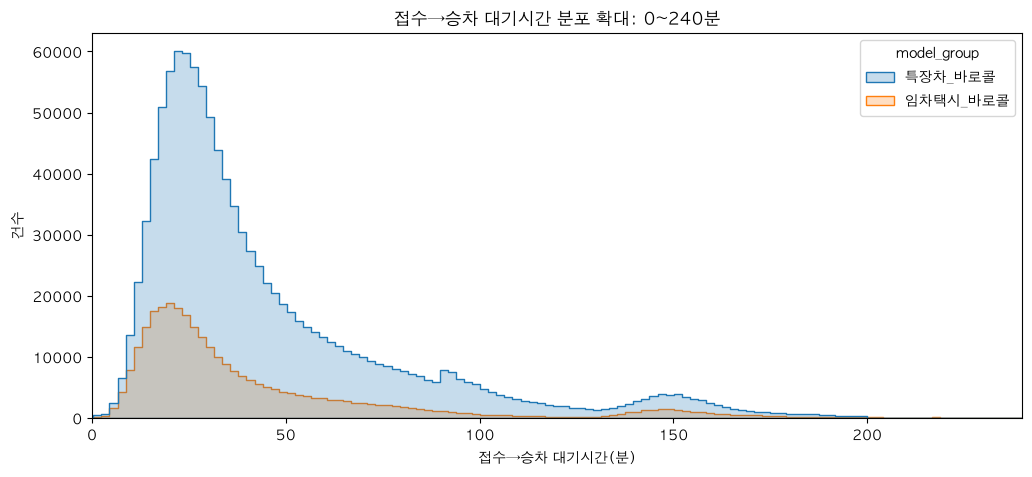

In [11]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=data,
    x="target_min",
    hue="model_group",
    bins=120,
    element="step",
    stat="count",
    common_norm=False,
)

plt.xlim(0, 240)
plt.title("접수→승차 대기시간 분포 확대: 0~240분")
plt.xlabel("접수→승차 대기시간(분)")
plt.ylabel("건수")
plt.show()

120~180분 구간 건수: 114433


,건수,평균,중앙값,p25,p75,최솟값,최댓값
model_group,,,,,,,
임차택시_바로콜,22643,144.33,147.31,137.20,156.96,100.0,180.0
특장차_바로콜,91790,134.84,138.79,112.98,152.60,100.0,180.0


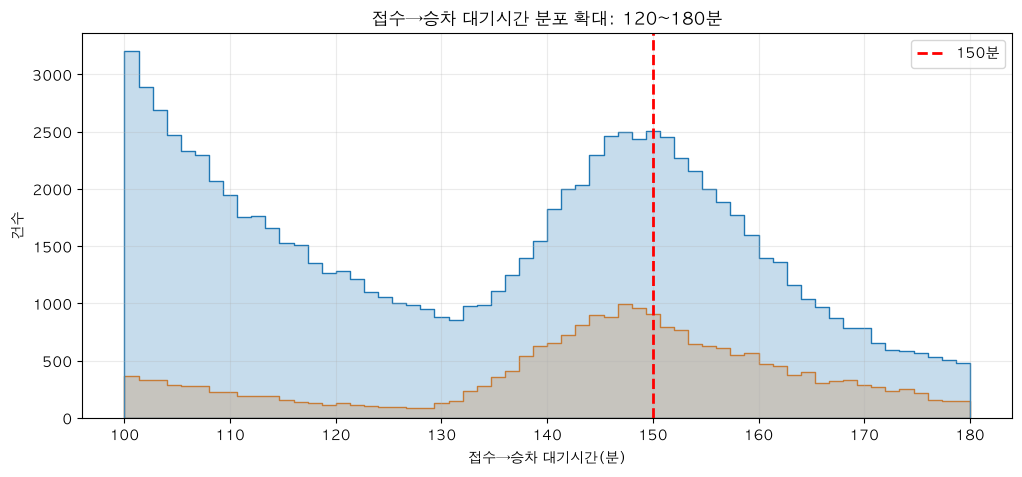

In [12]:
# =========================
# 150분 부근 확대: 120~180분
# =========================

zoom_data = data[
    data["target_min"].between(100, 180, inclusive="both")
].copy()

print("120~180분 구간 건수:", len(zoom_data))

display(
    zoom_data
    .groupby("model_group")["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        최솟값="min",
        최댓값="max",
    )
    .round(2)
)

plt.figure(figsize=(12, 5))

sns.histplot(
    data=zoom_data,
    x="target_min",
    hue="model_group",
    bins=60,
    element="step",
    stat="count",
    common_norm=False,
)

plt.axvline(150, color="red", linestyle="--", linewidth=2, label="150분")
plt.title("접수→승차 대기시간 분포 확대: 120~180분")
plt.xlabel("접수→승차 대기시간(분)")
plt.ylabel("건수")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

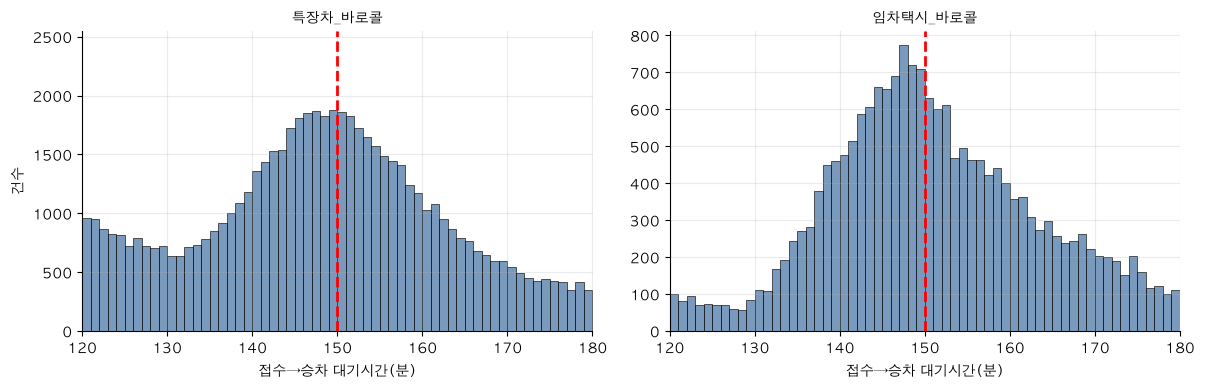

In [13]:
# =========================
# 차량유형별 150분 부근 분포 따로 보기
# =========================

g = sns.FacetGrid(
    zoom_data,
    col="model_group",
    height=4,
    aspect=1.5,
    sharey=False,
)

g.map_dataframe(
    sns.histplot,
    x="target_min",
    binwidth=1,
    color="#4e79a7",
)

for ax in g.axes.flat:
    ax.axvline(150, color="red", linestyle="--", linewidth=2)
    ax.set_xlim(120, 180)
    ax.grid(alpha=0.25)

g.set_axis_labels("접수→승차 대기시간(분)", "건수")
g.set_titles("{col_name}")
plt.show()

## 5. 02~06시 여부별 분포

In [14]:
data_time_compare = data.copy()

data_time_compare["시간구분"] = np.where(
    data_time_compare["hour"].between(2, 6, inclusive="both"),
    "02~06시",
    "그 외 시간",
)

dawn_compare = (
    data_time_compare
    .groupby(["model_group", "시간구분"])["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        최댓값="max",
    )
    .reset_index()
)

display(dawn_compare.round(2))

,model_group,시간구분,건수,평균,중앙값,p75,p90,p95,p99,최댓값
0,임차택시_바로콜,02~06시,16714,121.13,145.91,161.88,180.53,195.03,219.59,246.91
1,임차택시_바로콜,그 외 시간,289015,37.90,27.40,45.69,74.90,99.90,156.26,249.90
2,특장차_바로콜,02~06시,46271,103.50,106.87,155.69,172.75,182.83,194.65,199.99
3,특장차_바로콜,그 외 시간,1052813,43.75,32.62,54.33,89.26,111.66,156.25,199.92


In [15]:
# =========================
# 02~06시 데이터만 추출
# =========================

dawn_data = data[
    data["hour"].between(2, 6, inclusive="both")
].copy()

print("02~06시 데이터 건수:", len(dawn_data))

display(
    dawn_data
    .groupby("model_group")["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        p90=lambda x: x.quantile(0.90),
        최댓값="max",
    )
    .round(2)
)

02~06시 데이터 건수: 62985


,건수,평균,중앙값,p90,최댓값
model_group,,,,,
임차택시_바로콜,16714,121.13,145.91,180.53,246.91
특장차_바로콜,46271,103.50,106.87,172.75,199.99


## 6. 일반구간 모델링 데이터 생성

전체 데이터는 삭제하지 않고 보존한다.

다만 일반적인 대기시간 예측 모델은 아래 구간을 학습 대상에서 제외한 데이터로 만든다.

```text
제외 조건
1. 접수→승차 대기시간이 130분 초과
2. 접수시간대가 02~06시

In [16]:
# =========================
# 6. 일반구간 / 별도관리 데이터 분리
# =========================

long_wait_cutoff = 130

is_long_tail = data["target_min"].gt(long_wait_cutoff)
is_dawn_02_06 = data["hour"].between(2, 6, inclusive="both")

general_mask = ~is_long_tail & ~is_dawn_02_06

general_model_data = data[general_mask].copy()
excluded_model_data = data[~general_mask].copy()

print("전체 데이터:", data.shape)
print("일반구간 모델링 데이터:", general_model_data.shape)
print("별도관리 데이터:", excluded_model_data.shape)
print("별도관리 비율(%):", round(len(excluded_model_data) / len(data) * 100, 2))

전체 데이터: (1404813, 67)
일반구간 모델링 데이터: (1293478, 67)
별도관리 데이터: (111335, 67)
별도관리 비율(%): 7.93


In [17]:
# =========================
# 6-1. 제외 조건별 건수 확인
# =========================

exclude_summary = pd.Series({
    "전체 건수": len(data),
    "130분 초과 건수": is_long_tail.sum(),
    "02~06시 건수": is_dawn_02_06.sum(),
    "130분 초과 & 02~06시 건수": (is_long_tail & is_dawn_02_06).sum(),
    "130분 초과 비율(%)": is_long_tail.mean() * 100,
    "02~06시 비율(%)": is_dawn_02_06.mean() * 100,
    "겹침 비율 - 전체 대비(%)": (is_long_tail & is_dawn_02_06).mean() * 100,
    "별도관리 전체 비율(%)": (~general_mask).mean() * 100,
})

exclude_summary.round(2)

전체 건수                  1404813.00
130분 초과 건수               78429.00
02~06시 건수                62985.00
130분 초과 & 02~06시 건수      30079.00
130분 초과 비율(%)                5.58
02~06시 비율(%)                 4.48
겹침 비율 - 전체 대비(%)             2.14
별도관리 전체 비율(%)                7.93
dtype: float64

In [18]:
# =========================
# 6-2. 차량유형별 일반구간 / 별도관리 구분 확인
# =========================

data_exclude_check = data.copy()

data_exclude_check["모델링구분"] = np.where(
    general_mask,
    "일반구간_모델링",
    "별도관리_제외",
)

data_exclude_check["제외사유"] = np.select(
    [
        is_long_tail & is_dawn_02_06,
        is_long_tail,
        is_dawn_02_06,
    ],
    [
        "130분초과_AND_02~06시",
        "130분초과",
        "02~06시",
    ],
    default="일반구간",
)

exclude_by_group = (
    data_exclude_check
    .groupby(["model_group", "제외사유"])
    .agg(
        건수=("target_min", "size"),
        평균=("target_min", "mean"),
        중앙값=("target_min", "median"),
        p90=("target_min", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

exclude_by_group["전체대비비율(%)"] = exclude_by_group["건수"] / len(data) * 100

display(exclude_by_group.round(2))

,model_group,제외사유,건수,평균,중앙값,p90,전체대비비율(%)
0,임차택시_바로콜,02~06시,6667,58.32,55.86,96.93,0.47
1,임차택시_바로콜,130분초과,10767,151.95,148.25,171.70,0.77
2,임차택시_바로콜,130분초과_AND_02~06시,10047,162.81,158.17,192.16,0.72
3,임차택시_바로콜,일반구간,278248,33.49,26.61,65.97,19.81
4,특장차_바로콜,02~06시,26239,59.67,53.13,110.85,1.87
5,특장차_바로콜,130분초과,37583,151.28,149.14,169.18,2.68
6,특장차_바로콜,130분초과_AND_02~06시,20032,160.92,158.55,184.48,1.43
7,특장차_바로콜,일반구간,1015230,39.77,31.72,78.40,72.27


In [19]:
# =========================
# 6-3. 일반구간 모델링 데이터 분포 확인
# =========================

display(
    general_model_data
    .groupby("model_group")["target_min"]
    .agg(
        건수="count",
        평균="mean",
        중앙값="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        최댓값="max",
    )
    .round(2)
)

,건수,평균,중앙값,p75,p90,p95,최댓값
model_group,,,,,,,
임차택시_바로콜,278248,33.49,26.61,42.41,65.97,79.68,129.98
특장차_바로콜,1015230,39.77,31.72,50.62,78.40,94.12,130.00


## 7. train / validation / test 분리

기존 모델링과 동일하게 데이터를 70% / 15% / 15%로 나눈다.

분리 기준도 기존과 동일하게 `month × model_group`을 stratify 기준으로 사용한다.

이 방식은 월별 분포와 임차택시/특장차 비율이 train / validation / test에 비슷하게 유지되도록 하기 위한 것이다.

이번 모델에서는 일반구간 모델링 데이터인 `general_model_data`를 기준으로 분리한다.

In [20]:
# =========================
# 7. train / validation / test split 함수
# =========================

from sklearn.model_selection import train_test_split

def split_train_valid_test(frame):
    split_key = frame["month"].astype(str) + "_" + frame["model_group"].astype(str)

    train_df, temp_df = train_test_split(
        frame,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=split_key,
    )

    temp_split_key = temp_df["month"].astype(str) + "_" + temp_df["model_group"].astype(str)

    valid_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=temp_split_key,
    )

    train_df = train_df.sort_values("접수일시").reset_index(drop=True)
    valid_df = valid_df.sort_values("접수일시").reset_index(drop=True)
    test_df = test_df.sort_values("접수일시").reset_index(drop=True)

    return train_df, valid_df, test_df

In [21]:
# =========================
# 7-1. 일반구간 데이터 split
# =========================

train, valid, test = split_train_valid_test(general_model_data)

print("train:", train.shape)
print("valid:", valid.shape)
print("test:", test.shape)

train: (905434, 67)
valid: (194022, 67)
test: (194022, 67)


In [22]:
# =========================
# 7-2. split 결과 요약
# =========================

def split_summary(frame, name):
    return {
        "split": name,
        "rows": len(frame),
        "target_mean": frame["target_min"].mean(),
        "target_median": frame["target_min"].median(),
        "target_p90": frame["target_min"].quantile(0.90),
        "target_max": frame["target_min"].max(),
        "min_date": frame["접수일시"].min(),
        "max_date": frame["접수일시"].max(),
    }


split_summary_df = pd.DataFrame([
    split_summary(train, "train"),
    split_summary(valid, "valid"),
    split_summary(test, "test"),
])

display(split_summary_df.round(4))

/var/folders/br/x7f7fw1907z6wpb38fpn1kpm0000gn/T/ipykernel_33530/3316341817.py:24: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(split_summary_df.round(4))


,split,rows,target_mean,target_median,target_p90,target_max,min_date,max_date
0,train,905434,38.4277,30.6120,75.6889,129.9986,2025-01-01 00:01:26.127,2025-12-31 23:31:37.000
1,valid,194022,38.4567,30.6165,75.6732,129.9884,2025-01-01 00:03:40.573,2025-12-31 23:52:59.000
2,test,194022,38.3580,30.5818,75.4802,129.9927,2025-01-01 00:03:31.230,2025-12-31 23:40:56.080


In [23]:
# =========================
# 7-3. model_group 비율 확인
# =========================

model_group_ratio = pd.concat(
    [
        train["model_group"].value_counts(normalize=True).rename("train"),
        valid["model_group"].value_counts(normalize=True).rename("valid"),
        test["model_group"].value_counts(normalize=True).rename("test"),
    ],
    axis=1,
)

display(model_group_ratio.round(4))

,train,valid,test
model_group,,,
특장차_바로콜,0.7849,0.7849,0.7849
임차택시_바로콜,0.2151,0.2151,0.2151


In [24]:
# =========================
# 7-4. month 비율 확인
# =========================

month_ratio = pd.concat(
    [
        train["month"].value_counts(normalize=True).sort_index().rename("train"),
        valid["month"].value_counts(normalize=True).sort_index().rename("valid"),
        test["month"].value_counts(normalize=True).sort_index().rename("test"),
    ],
    axis=1,
)

display(month_ratio.round(4))

,train,valid,test
month,,,
1,0.0745,0.0745,0.0745
2,0.0774,0.0774,0.0774
3,0.0819,0.0819,0.0819
4,0.0852,0.0852,0.0852
5,0.0806,0.0806,0.0806
6,0.0822,0.0822,0.0822
7,0.0945,0.0945,0.0945
8,0.0875,0.0875,0.0875
9,0.0881,0.0881,0.0881


In [25]:
model_group_ratio = pd.concat(
    [
        train["model_group"].value_counts(normalize=True).rename("train"),
        valid["model_group"].value_counts(normalize=True).rename("valid"),
        test["model_group"].value_counts(normalize=True).rename("test"),
    ],
    axis=1,
)

display(model_group_ratio.round(4))

,train,valid,test
model_group,,,
특장차_바로콜,0.7849,0.7849,0.7849
임차택시_바로콜,0.2151,0.2151,0.2151


## 8. Feature Set v2: RF 모델링

이번 실험에서는 거리 피처를 `승차거리_km`가 아니라 원본 컬럼인 `승차거리`로 통일한다.

사용 피처는 아래 11개다.

```python
FEATURES_V2 = [
    "hour",
    "이용목적",
    "승차거리",
    "출발동",
    "목적동",
    "출발구",
    "목적구",
    "month",
    "세부이동유형",
    "dayofweek",
    "model_group",
]
```

주의:

- `접수_승차_분`, `접수_배차_분`, `배차_승차_분`은 결과 이후에 알 수 있는 값이므로 모델 입력에서 제외한다.
- `접수시간대`, `접수시간대_HH`, `접수시`는 `hour`와 중복되므로 제외한다.
- 이 노트북은 RandomForest 모델 기준이다. RandomForest는 GPU를 직접 사용하지 않으므로 Colab에서는 CPU 병렬 처리(`n_jobs=-1`)로 실행한다.

In [26]:
# =========================
# 8-1. Feature Set v2 정의
# =========================

FEATURES_V2 = [
    "hour",
    "이용목적",
    "승차거리",
    "출발동",
    "목적동",
    "출발구",
    "목적구",
    "month",
    "세부이동유형",
    "dayofweek",
    "model_group",
]

TARGET_COL = "target_min"

missing_features = [col for col in FEATURES_V2 if col not in train.columns]
if missing_features:
    raise ValueError(f"train에 없는 피처가 있습니다: {missing_features}")

# 승차거리는 모델 입력용 수치형으로 통일
for frame in [train, valid, test]:
    frame["승차거리"] = pd.to_numeric(frame["승차거리"], errors="coerce")

print("FEATURES_V2 개수:", len(FEATURES_V2))
print(FEATURES_V2)

display(train[FEATURES_V2 + [TARGET_COL]].head())

FEATURES_V2 개수: 11
['hour', '이용목적', '승차거리', '출발동', '목적동', '출발구', '목적구', 'month', '세부이동유형', 'dayofweek', 'model_group']


,hour,이용목적,승차거리,출발동,목적동,출발구,목적구,month,세부이동유형,dayofweek,model_group,target_min
0,0,기타,17667,남영동,수유제2동,용산구,강북구,1,구 간 이동,2,특장차_바로콜,48.447333
1,0,기타,4858,상일동,성내제2동,강동구,강동구,1,구 내 이동,2,특장차_바로콜,52.051550
2,0,귀가,5145,중계2.3동,상계1동,노원구,노원구,1,구 내 이동,2,특장차_바로콜,38.206117
3,0,기타,9000,이화동,월계2동,종로구,노원구,1,구 간 이동,2,특장차_바로콜,92.664717
4,0,귀가,9702,여의동,증산동,영등포구,은평구,1,구 간 이동,2,특장차_바로콜,82.073717


## 9. 평가 함수 정의

회귀 성능은 MAE, Median AE, RMSE, R²로 확인한다.

장시간 대기 위험 예측 성능은 train set의 `target_min` 90분위수를 기준으로 Accuracy, Precision, Recall, F1을 확인한다.

In [27]:
# =========================
# 9-1. 평가 함수
# =========================

from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "Median_AE": median_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def risk_metrics(y_true, y_pred, threshold):
    actual = y_true >= threshold
    pred = y_pred >= threshold
    return {
        "threshold": threshold,
        "Accuracy": accuracy_score(actual, pred),
        "Precision": precision_score(actual, pred, zero_division=0),
        "Recall": recall_score(actual, pred, zero_division=0),
        "F1": f1_score(actual, pred, zero_division=0),
        "Confusion_Matrix": confusion_matrix(actual, pred, labels=[False, True]).tolist(),
    }


def evaluate_predictions(frame, pred, threshold):
    y = frame["target_min"].to_numpy()
    return {
        **regression_metrics(y, pred),
        **{f"risk_{k}": v for k, v in risk_metrics(y, pred, threshold).items()},
    }


## 10. RandomForest 모델 학습

범주형 변수는 `OrdinalEncoder`로 변환하고, 수치형 변수는 그대로 사용한다.

이번 피처셋은 `출발동`, `목적동`처럼 고유값이 많은 범주형 변수를 포함하므로, One-Hot Encoding보다 메모리 부담이 작은 Ordinal Encoding을 사용한다.

In [28]:
# =========================
# 10-1. RandomForest Pipeline 구성
# =========================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

CATEGORICAL_COLS_V2 = [
    "이용목적",
    "출발동",
    "목적동",
    "출발구",
    "목적구",
    "세부이동유형",
    "model_group",
]

NUMERIC_COLS_V2 = [
    "hour",
    "승차거리",
    "month",
    "dayofweek",
]


def build_rf_v2_pipeline(params=None):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                ),
                CATEGORICAL_COLS_V2,
            ),
            (
                "num",
                "passthrough",
                NUMERIC_COLS_V2,
            ),
        ],
        remainder="drop",
    )

    default_params = {
        "n_estimators": 100,
        "max_depth": 26,
        "min_samples_leaf": 5,
        "max_features": 0.8,
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
        "verbose": 1,
    }

    if params:
        default_params.update(params)

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(**default_params)),
    ])

In [29]:
# =========================
# 10-2. RandomForest 모델 학습 및 평가
# =========================

long_wait_threshold_v2 = train[TARGET_COL].quantile(0.90)
threshold_by_group_v2 = train.groupby("model_group")[TARGET_COL].quantile(0.90).to_dict()

print("장시간 대기 기준 p90:", round(long_wait_threshold_v2, 4))
print("차량유형별 p90:", {k: round(v, 4) for k, v in threshold_by_group_v2.items()})

rf_v2_model = build_rf_v2_pipeline()

rf_v2_model.fit(
    train[FEATURES_V2],
    train[TARGET_COL],
)

valid_pred_rf_v2 = rf_v2_model.predict(valid[FEATURES_V2])
test_pred_rf_v2 = rf_v2_model.predict(test[FEATURES_V2])

valid_metrics_rf_v2 = evaluate_predictions(
    valid,
    valid_pred_rf_v2,
    threshold=long_wait_threshold_v2,
)

test_metrics_rf_v2 = evaluate_predictions(
    test,
    test_pred_rf_v2,
    threshold=long_wait_threshold_v2,
)

rf_v2_results = pd.DataFrame([
    {"model": "RandomForest Feature Set v2", "split": "valid", **valid_metrics_rf_v2},
    {"model": "RandomForest Feature Set v2", "split": "test", **test_metrics_rf_v2},
])

display(
    rf_v2_results
    .drop(columns=["risk_Confusion_Matrix"])
    .round(4)
)

print("test confusion matrix:")
test_metrics_rf_v2["risk_Confusion_Matrix"]

장시간 대기 기준 p90: 75.6889
차량유형별 p90: {'임차택시_바로콜': 66.0455, '특장차_바로콜': 78.443}


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   14.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   37.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished


,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,RandomForest Feature Set v2,valid,11.6665,8.3899,16.1661,0.5587,75.6889,0.9206,0.7007,0.3580,0.4739
1,RandomForest Feature Set v2,test,11.7173,8.4350,16.2173,0.5537,75.6889,0.9205,0.6947,0.3537,0.4687


test confusion matrix:


[[171802, 2989], [12429, 6802]]

## 11. 차량유형별 성능 확인

통합 모델이 임차택시 바로콜과 특장차 바로콜에서 각각 어떻게 동작하는지 따로 확인한다.

#### 모델 성능평가 지표

| 지표 | 의미 | 해석 방법 | 이 프로젝트에서의 활용 |
|---|---|---|---|
| `MAE` | 실제 대기시간과 예측 대기시간의 절대 오차 평균 | 평균적으로 몇 분 정도 틀리는지 나타냄 | 네비게이터에 표시할 예상 대기시간의 실사용 오차를 가장 직관적으로 보여주므로 최우선 지표로 사용 |
| `Median_AE` | 절대 오차의 중앙값 | 전체 호출 중 절반은 이 오차 이하로 예측됨 | 일부 극단적인 오차에 덜 민감하므로 일반적인 사용자 체감 오차를 확인하는 보조 지표 |
| `RMSE` | 오차 제곱 평균의 제곱근 | 큰 오차가 있을수록 값이 크게 증가함 | 장시간 대기처럼 크게 틀린 사례가 많은지 확인하는 지표 |
| `R²` | 모델이 대기시간 변동을 얼마나 설명하는지 나타내는 설명력 지표 | 1에 가까울수록 설명력이 높고, 0에 가까울수록 평균 예측과 큰 차이가 없음 | 모델이 전체 대기시간 패턴을 어느 정도 설명하는지 참고용으로 사용 |
| `risk_Accuracy` | 장시간 대기 여부를 맞춘 전체 비율 | 일반 대기와 장시간 대기를 모두 포함해 맞춘 비율 | 장시간 대기 비율이 낮으면 높게 나올 수 있어 단독 해석은 주의 |
| `risk_Precision` | 모델이 장시간 대기라고 예측한 것 중 실제 장시간 대기인 비율 | 높을수록 잘못된 장시간 대기 경고가 적음 | 사용자에게 불필요한 경고를 줄이는 관점에서 참고 |
| `risk_Recall` | 실제 장시간 대기 중 모델이 잡아낸 비율 | 높을수록 장시간 대기를 놓치지 않음 | 대체수단 안내나 위험 경고 기능을 만들 때 중요 |
| `risk_F1` | Precision과 Recall의 균형 지표 | Precision과 Recall을 함께 고려한 점수 | 장시간 대기 경고 모델의 종합 성능을 볼 때 사용 |

In [30]:
# =========================
# 11-1. 차량유형별 성능 평가
# =========================

def evaluate_by_group(frame, pred, threshold_by_group):
    tmp = frame[["model_group", TARGET_COL]].copy()
    tmp["prediction"] = pred

    rows = []
    for group, group_df in tmp.groupby("model_group"):
        y = group_df[TARGET_COL].to_numpy()
        p = group_df["prediction"].to_numpy()
        threshold = threshold_by_group[group]

        reg = regression_metrics(y, p)
        risk = risk_metrics(y, p, threshold)

        rows.append({
            "model_group": group,
            "rows": len(group_df),
            **reg,
            "risk_threshold": threshold,
            "risk_Accuracy": risk["Accuracy"],
            "risk_Precision": risk["Precision"],
            "risk_Recall": risk["Recall"],
            "risk_F1": risk["F1"],
        })

    return pd.DataFrame(rows)


group_metrics_rf_v2 = evaluate_by_group(
    test,
    test_pred_rf_v2,
    threshold_by_group_v2,
)

display(group_metrics_rf_v2.round(4))

,model_group,rows,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,임차택시_바로콜,41738,10.4397,7.5704,14.3818,0.5517,66.0455,0.9212,0.6606,0.3832,0.4850
1,특장차_바로콜,152284,12.0675,8.7128,16.6851,0.5475,78.4430,0.9194,0.6901,0.3363,0.4522


## 12. 결과 해석 메모 작성 위치

실행 후 아래 항목을 확인한다.

- 전체 test MAE
- 전체 test RMSE
- 전체 test R²
- 장시간 대기 Recall / F1
- 임차택시 바로콜과 특장차 바로콜의 그룹별 성능 차이
- 기존 최종 RF 성능과 비교

기존 최종 RF 기준 성능은 다음과 같다.

```text
MAE: 15.06
RMSE: 23.51
R²: 0.573
Recall: 0.421
F1: 0.548
```

## 13. Proxy 추가: 출발구×요일×시간대 평소 대기시간

MAE를 줄이기 위해 `출발구 × 요일 × 시간대` 조합별 평소 대기시간을 proxy 피처로 추가한다.

추가 피처는 다음과 같다.

```python
origin_gu_weekday_hour_wait_p50
```

이 변수는 `target_min`의 중앙값을 이용해 만들기 때문에 target leakage 위험이 있다.  
따라서 전체 데이터를 한 번에 집계해서 붙이지 않고, 아래 방식으로 생성한다.

- train set: OOF 방식으로 생성
  - 각 fold의 값은 자기 fold를 제외한 나머지 train fold에서만 계산
  - 각 행이 자기 자신의 `target_min`을 직접 참조하지 않도록 함
- validation/test set: train 전체에서 계산한 통계값만 merge
  - validation/test의 정답 정보는 proxy 생성에 사용하지 않음

주의: 이 방식은 모델 검증 시 validation/test leakage를 막기 위한 방식이다. 실제 서비스 적용 시에는 예측 시점 이전의 누적 이력 데이터만 사용해 동일한 통계를 계산해야 한다.

In [31]:
# =========================
# 13-1. OOF target-stat proxy 생성 함수
# =========================

from sklearn.model_selection import StratifiedKFold, KFold


def add_oof_group_target_stat(
    train_df,
    valid_df,
    test_df,
    group_cols,
    target_col,
    stat_name,
    agg_func="median",
    n_splits=5,
    random_state=42,
):
    """target 기반 group 통계 proxy를 leakage 방지 방식으로 생성한다.

    train:
        OOF 방식으로 각 fold의 proxy를 나머지 fold에서 계산한다.
    valid/test:
        train 전체에서 계산한 통계표만 merge한다.
    """
    train_result = train_df.copy()
    valid_result = valid_df.copy()
    test_result = test_df.copy()

    global_stat = train_result[target_col].agg(agg_func)
    train_result[stat_name] = np.nan

    # 기존 분리 기준과 비슷하게 month × model_group 분포를 유지하면서 OOF fold 생성
    if {"month", "model_group"}.issubset(train_result.columns):
        strata = train_result["month"].astype(str) + "_" + train_result["model_group"].astype(str)
        splitter = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state,
        )
        split_iter = splitter.split(train_result, strata)
    else:
        splitter = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state,
        )
        split_iter = splitter.split(train_result)

    for fold_idx, (fit_idx, oof_idx) in enumerate(split_iter, start=1):
        fold_fit = train_result.iloc[fit_idx]
        fold_oof_keys = train_result.iloc[oof_idx][group_cols]

        stat_table = (
            fold_fit
            .groupby(group_cols, observed=True)[target_col]
            .agg(agg_func)
            .reset_index()
            .rename(columns={target_col: stat_name})
        )

        mapped = fold_oof_keys.merge(
            stat_table,
            on=group_cols,
            how="left",
        )[stat_name].to_numpy()

        train_result.iloc[oof_idx, train_result.columns.get_loc(stat_name)] = mapped
        print(f"fold {fold_idx}/{n_splits} 완료")

    # 희소 조합은 전체 train target 중앙값으로 보완
    train_result[stat_name] = train_result[stat_name].fillna(global_stat)

    # valid/test는 train 전체에서 계산한 통계값만 사용
    full_stat_table = (
        train_df
        .groupby(group_cols, observed=True)[target_col]
        .agg(agg_func)
        .reset_index()
        .rename(columns={target_col: stat_name})
    )

    valid_result = valid_result.merge(full_stat_table, on=group_cols, how="left")
    test_result = test_result.merge(full_stat_table, on=group_cols, how="left")

    valid_result[stat_name] = valid_result[stat_name].fillna(global_stat)
    test_result[stat_name] = test_result[stat_name].fillna(global_stat)

    return train_result, valid_result, test_result, full_stat_table


In [32]:
# =========================
# 13-2. 출발구 × 요일 × 시간대 p50 proxy 생성
# =========================

ORIGIN_GU_WEEKDAY_HOUR_COLS = [
    "출발구",
    "dayofweek",
    "hour",
]

ORIGIN_GU_WEEKDAY_HOUR_P50_COL = "origin_gu_weekday_hour_wait_p50"

train_p50, valid_p50, test_p50, origin_gu_weekday_hour_wait_p50_table = (
    add_oof_group_target_stat(
        train,
        valid,
        test,
        group_cols=ORIGIN_GU_WEEKDAY_HOUR_COLS,
        target_col=TARGET_COL,
        stat_name=ORIGIN_GU_WEEKDAY_HOUR_P50_COL,
        agg_func="median",
        n_splits=5,
        random_state=RANDOM_STATE,
    )
)

print("proxy 생성 후 shape:")
print("train_p50:", train_p50.shape)
print("valid_p50:", valid_p50.shape)
print("test_p50:", test_p50.shape)

print("proxy 결측치 수:")
print("train:", train_p50[ORIGIN_GU_WEEKDAY_HOUR_P50_COL].isna().sum())
print("valid:", valid_p50[ORIGIN_GU_WEEKDAY_HOUR_P50_COL].isna().sum())
print("test:", test_p50[ORIGIN_GU_WEEKDAY_HOUR_P50_COL].isna().sum())

display(
    train_p50[
        ORIGIN_GU_WEEKDAY_HOUR_COLS
        + [ORIGIN_GU_WEEKDAY_HOUR_P50_COL, TARGET_COL]
    ].head()
)

display(
    origin_gu_weekday_hour_wait_p50_table
    .sort_values(ORIGIN_GU_WEEKDAY_HOUR_P50_COL, ascending=False)
    .head(20)
    .round(4)
)


fold 1/5 완료
fold 2/5 완료
fold 3/5 완료
fold 4/5 완료
fold 5/5 완료
proxy 생성 후 shape:
train_p50: (905434, 68)
valid_p50: (194022, 68)
test_p50: (194022, 68)
proxy 결측치 수:
train: 0
valid: 0
test: 0


,출발구,dayofweek,hour,origin_gu_weekday_hour_wait_p50,target_min
0,용산구,2,0,29.332450,48.447333
1,강동구,2,0,49.637358,52.051550
2,노원구,2,0,23.979117,38.206117
3,종로구,2,0,39.193067,92.664717
4,영등포구,2,0,48.674667,82.073717


,출발구,dayofweek,hour,origin_gu_weekday_hour_wait_p50
2553,성남시분당구,0,17,129.7478
2221,부천시오정구,4,18,129.6338
2270,부천시원미구,5,14,129.5682
1492,남양주시,6,9,129.5570
704,과천시,2,13,129.4106
2545,서초구,6,22,128.9359
2641,성남시수정구,5,16,128.7950
602,고양시덕양구,6,17,128.7722
3118,안양시만안구,6,12,128.6480
3105,안양시만안구,3,9,128.5662


## 14. RF + 출발구×요일×시간대 p50 proxy 재학습

기존 Feature Set v2에 `origin_gu_weekday_hour_wait_p50`을 추가해 RandomForest 모델을 다시 학습한다.

비교 기준은 기존과 동일하다.

1. `MAE`
2. `Median_AE`
3. `RMSE`
4. `R2`
5. `risk_F1`

이번 실험의 핵심 목적은 장시간 대기 탐지보다 `MAE`가 줄어드는지 확인하는 것이다.

In [33]:
# =========================
# 14-1. proxy 추가 Feature Set 정의
# =========================

FEATURES_V2_P50 = FEATURES_V2 + [
    ORIGIN_GU_WEEKDAY_HOUR_P50_COL,
]

NUMERIC_COLS_V2_P50 = NUMERIC_COLS_V2 + [
    ORIGIN_GU_WEEKDAY_HOUR_P50_COL,
]

missing_features = [col for col in FEATURES_V2_P50 if col not in train_p50.columns]
if missing_features:
    raise ValueError(f"train_p50에 없는 피처가 있습니다: {missing_features}")

print("기존 피처 수:", len(FEATURES_V2))
print("p50 proxy 추가 후 피처 수:", len(FEATURES_V2_P50))
print(FEATURES_V2_P50)

display(train_p50[FEATURES_V2_P50 + [TARGET_COL]].head())


기존 피처 수: 11
p50 proxy 추가 후 피처 수: 12
['hour', '이용목적', '승차거리', '출발동', '목적동', '출발구', '목적구', 'month', '세부이동유형', 'dayofweek', 'model_group', 'origin_gu_weekday_hour_wait_p50']


,hour,이용목적,승차거리,출발동,목적동,출발구,목적구,month,세부이동유형,dayofweek,model_group,origin_gu_weekday_hour_wait_p50,target_min
0,0,기타,17667,남영동,수유제2동,용산구,강북구,1,구 간 이동,2,특장차_바로콜,29.332450,48.447333
1,0,기타,4858,상일동,성내제2동,강동구,강동구,1,구 내 이동,2,특장차_바로콜,49.637358,52.051550
2,0,귀가,5145,중계2.3동,상계1동,노원구,노원구,1,구 내 이동,2,특장차_바로콜,23.979117,38.206117
3,0,기타,9000,이화동,월계2동,종로구,노원구,1,구 간 이동,2,특장차_바로콜,39.193067,92.664717
4,0,귀가,9702,여의동,증산동,영등포구,은평구,1,구 간 이동,2,특장차_바로콜,48.674667,82.073717


In [34]:
# =========================
# 14-2. proxy 추가 RF Pipeline 구성
# =========================


def build_rf_v2_p50_pipeline(params=None):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                ),
                CATEGORICAL_COLS_V2,
            ),
            (
                "num",
                "passthrough",
                NUMERIC_COLS_V2_P50,
            ),
        ],
        remainder="drop",
    )

    default_params = {
        "n_estimators": 100,
        "max_depth": 26,
        "min_samples_leaf": 5,
        "max_features": 0.8,
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
        "verbose": 1,
    }

    if params:
        default_params.update(params)

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(**default_params)),
    ])


In [35]:
# =========================
# 14-3. RF + p50 proxy 학습 및 평가
# =========================

rf_v2_p50_model = build_rf_v2_p50_pipeline()

rf_v2_p50_model.fit(
    train_p50[FEATURES_V2_P50],
    train_p50[TARGET_COL],
)

valid_pred_rf_v2_p50 = rf_v2_p50_model.predict(valid_p50[FEATURES_V2_P50])
test_pred_rf_v2_p50 = rf_v2_p50_model.predict(test_p50[FEATURES_V2_P50])

valid_metrics_rf_v2_p50 = evaluate_predictions(
    valid_p50,
    valid_pred_rf_v2_p50,
    threshold=long_wait_threshold_v2,
)

test_metrics_rf_v2_p50 = evaluate_predictions(
    test_p50,
    test_pred_rf_v2_p50,
    threshold=long_wait_threshold_v2,
)

rf_v2_p50_results = pd.DataFrame([
    {"model": "RandomForest Feature Set v2 + origin_gu_weekday_hour_wait_p50", "split": "valid", **valid_metrics_rf_v2_p50},
    {"model": "RandomForest Feature Set v2 + origin_gu_weekday_hour_wait_p50", "split": "test", **test_metrics_rf_v2_p50},
])

display(
    rf_v2_p50_results
    .drop(columns=["risk_Confusion_Matrix"], errors="ignore")
    .round(4)
)

print("test confusion matrix:")
test_metrics_rf_v2_p50["risk_Confusion_Matrix"]


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   50.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.0s finished


,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,RandomForest Feature Set v2 + origin_gu_weekda...,valid,11.7988,8.5284,16.3214,0.5502,75.6889,0.9195,0.6944,0.3470,0.4627
1,RandomForest Feature Set v2 + origin_gu_weekda...,test,11.8240,8.5198,16.3666,0.5455,75.6889,0.9198,0.6892,0.3476,0.4622


test confusion matrix:


[[171777, 3014], [12546, 6685]]

## 15. 기존 RF 기준 성능과 proxy 추가 성능 비교

기존 Feature Set v2 RF 결과와 `origin_gu_weekday_hour_wait_p50` proxy 추가 결과를 비교한다.

해석 기준은 다음과 같다.

- `MAE`가 줄면 예상 대기시간 제공 성능이 개선된 것
- `Median_AE`가 줄면 일반적인 사용자 체감 오차가 개선된 것
- `RMSE`가 줄면 큰 오차가 줄어든 것
- `risk_F1`은 장시간 대기 탐지 관점의 참고 지표

In [36]:
# =========================
# 15-1. RF baseline vs p50 proxy 비교
# =========================

rf_proxy_compare = pd.concat(
    [
        rf_v2_results.assign(feature_set="Feature Set v2"),
        rf_v2_p50_results.assign(feature_set="Feature Set v2 + origin_gu_weekday_hour_wait_p50"),
    ],
    ignore_index=True,
)

compare_cols = [
    "feature_set",
    "model",
    "split",
    "MAE",
    "Median_AE",
    "RMSE",
    "R2",
    "risk_threshold",
    "risk_Accuracy",
    "risk_Precision",
    "risk_Recall",
    "risk_F1",
]

display(
    rf_proxy_compare[compare_cols]
    .sort_values(["split", "MAE"])
    .round(4)
)

# test 기준 개선폭 확인
baseline_test = rf_v2_results.query("split == 'test'").iloc[0]
p50_test = rf_v2_p50_results.query("split == 'test'").iloc[0]

improvement_summary = pd.DataFrame([
    {
        "metric": "MAE",
        "baseline": baseline_test["MAE"],
        "p50_proxy": p50_test["MAE"],
        "diff_p50_minus_baseline": p50_test["MAE"] - baseline_test["MAE"],
    },
    {
        "metric": "Median_AE",
        "baseline": baseline_test["Median_AE"],
        "p50_proxy": p50_test["Median_AE"],
        "diff_p50_minus_baseline": p50_test["Median_AE"] - baseline_test["Median_AE"],
    },
    {
        "metric": "RMSE",
        "baseline": baseline_test["RMSE"],
        "p50_proxy": p50_test["RMSE"],
        "diff_p50_minus_baseline": p50_test["RMSE"] - baseline_test["RMSE"],
    },
    {
        "metric": "risk_F1",
        "baseline": baseline_test["risk_F1"],
        "p50_proxy": p50_test["risk_F1"],
        "diff_p50_minus_baseline": p50_test["risk_F1"] - baseline_test["risk_F1"],
    },
])

display(improvement_summary.round(4))


,feature_set,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
1,Feature Set v2,RandomForest Feature Set v2,test,11.7173,8.4350,16.2173,0.5537,75.6889,0.9205,0.6947,0.3537,0.4687
3,Feature Set v2 + origin_gu_weekday_hour_wait_p50,RandomForest Feature Set v2 + origin_gu_weekda...,test,11.8240,8.5198,16.3666,0.5455,75.6889,0.9198,0.6892,0.3476,0.4622
0,Feature Set v2,RandomForest Feature Set v2,valid,11.6665,8.3899,16.1661,0.5587,75.6889,0.9206,0.7007,0.3580,0.4739
2,Feature Set v2 + origin_gu_weekday_hour_wait_p50,RandomForest Feature Set v2 + origin_gu_weekda...,valid,11.7988,8.5284,16.3214,0.5502,75.6889,0.9195,0.6944,0.3470,0.4627


,metric,baseline,p50_proxy,diff_p50_minus_baseline
0,MAE,11.7173,11.8240,0.1067
1,Median_AE,8.4350,8.5198,0.0848
2,RMSE,16.2173,16.3666,0.1493
3,risk_F1,0.4687,0.4622,-0.0066


In [37]:
# =========================
# 15-2. proxy 추가 모델 차량유형별 성능 평가
# =========================

group_metrics_rf_v2_p50 = evaluate_by_group(
    test_p50,
    test_pred_rf_v2_p50,
    threshold_by_group_v2,
)

display(group_metrics_rf_v2_p50.round(4))


,model_group,rows,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,임차택시_바로콜,41738,10.5742,7.6722,14.5904,0.5386,66.0455,0.9207,0.6646,0.3652,0.4713
1,특장차_바로콜,152284,12.1666,8.7876,16.8207,0.5401,78.4430,0.9188,0.6871,0.3296,0.4455


## 16. 해석 메모

`origin_gu_weekday_hour_wait_p50`은 출발구·요일·시간대별 평소 대기시간을 반영하는 proxy이다.

이 피처는 `target_min` 기반이므로 leakage 위험이 있지만, 본 실험에서는 다음 방식으로 방지하였다.

- train set에서는 OOF 방식으로 proxy를 생성했다.
- validation/test set에서는 train set에서 계산한 통계값만 사용했다.
- 따라서 validation/test의 정답 대기시간은 proxy 생성에 사용되지 않았다.

결과 해석 시에는 기존 RF Feature Set v2 대비 MAE가 감소했는지를 가장 우선적으로 확인한다.  
MAE가 감소했다면 지역·요일·시간대별 평소 대기시간 패턴이 예상 대기시간 예측에 도움이 된 것으로 볼 수 있다.


=> 출발구×요일×시간대 중앙 대기시간 proxy는 leakage를 방지해 생성했으나, MAE 개선 효과가 없어 최종 모델에서는 제외하였다.

## 17. 공급 proxy 실험 A: 당일 차량운행 대수 추가

현재 모델은 시간, 지역, 이동유형, 거리 등 호출 자체의 특성은 포함하지만, 공급 측 변수는 부족하다.

따라서 서울시설공단 장애인콜택시 일별이용현황 데이터의 `차량운행` 컬럼을 공급 proxy로 추가한다.

이번 실험 A에서는 `접수일자 = 기준일` 기준으로 당일 차량운행 대수를 붙인다.

```python
vehicle_operation_count_today
```

의미:

```text
해당 접수일자에 운행한 장애인콜택시 차량 대수
```

주의:

- `차량운행`은 실시간 배차 가능 차량 수가 아니라 일별 전체 운행 차량 수이다.
- 당일 최종 운행대수는 하루가 끝난 뒤 확정되는 값일 수 있으므로, 실서비스 예측 피처로는 leakage 논란이 있을 수 있다.
- 따라서 이 실험은 공급량 proxy가 성능에 도움이 되는지 확인하는 성능 비교용 실험으로 해석한다.
- 실서비스 적용 가능성을 더 엄격히 보려면 다음 단계에서 전일 차량운행 대수(`prev_day`)를 사용한다.

In [38]:
# =========================
# 17-1. 일별이용현황 데이터 로드
# =========================

DAILY_USAGE_FILENAME = "서울시설공단_장애인콜택시 일별이용현황_20251231.csv"
DAILY_USAGE_PATH = find_csv_in_processed(DATA_DIR, DAILY_USAGE_FILENAME)

print("DAILY_USAGE_PATH:", DAILY_USAGE_PATH)

daily_usage = pd.read_csv(DAILY_USAGE_PATH, low_memory=False)

required_daily_cols = ["기준일", "차량운행"]
missing_daily_cols = [col for col in required_daily_cols if col not in daily_usage.columns]
if missing_daily_cols:
    raise ValueError(f"일별이용현황 데이터에 필요한 컬럼이 없습니다: {missing_daily_cols}")

daily_usage["기준일"] = pd.to_datetime(daily_usage["기준일"], errors="coerce").dt.normalize()
daily_usage["차량운행"] = pd.to_numeric(daily_usage["차량운행"], errors="coerce")

vehicle_operation_today_table = (
    daily_usage
    .dropna(subset=["기준일"])
    .groupby("기준일", as_index=False)
    .agg(vehicle_operation_count_today=("차량운행", "first"))
)

print("일별 차량운행 table shape:", vehicle_operation_today_table.shape)
print("기준일 범위:", vehicle_operation_today_table["기준일"].min(), "~", vehicle_operation_today_table["기준일"].max())

display(vehicle_operation_today_table.head())
display(vehicle_operation_today_table["vehicle_operation_count_today"].describe().to_frame().round(2))


DAILY_USAGE_PATH: /Users/blaumonde/calltaxi-DA/data/processed/서울시설공단_장애인콜택시 일별이용현황_20251231.csv
일별 차량운행 table shape: (365, 2)
기준일 범위: 2025-01-01 00:00:00 ~ 2025-12-31 00:00:00


,기준일,vehicle_operation_count_today
0,2025-01-01,257
1,2025-01-02,665
2,2025-01-03,655
3,2025-01-04,407
4,2025-01-05,242


,vehicle_operation_count_today
count,365.00
mean,594.46
std,213.29
min,207.00
25%,340.00
50%,680.00
75%,772.00
max,853.00


In [39]:
# =========================
# 17-2. train / valid / test에 당일 차량운행 merge
# =========================

TODAY_VEHICLE_OPERATION_COL = "vehicle_operation_count_today"


def add_today_vehicle_operation_count(train_df, valid_df, test_df, daily_table):
    result_frames = []

    # train 기준 중앙값으로 결측 보완
    train_dates = train_df["접수일시"].dt.normalize()
    train_daily_values = train_dates.to_frame(name="기준일").merge(
        daily_table,
        on="기준일",
        how="left",
    )[TODAY_VEHICLE_OPERATION_COL]
    fallback_value = train_daily_values.median()

    for name, frame in [
        ("train", train_df),
        ("valid", valid_df),
        ("test", test_df),
    ]:
        tmp = frame.copy()
        tmp["_merge_기준일"] = tmp["접수일시"].dt.normalize()

        tmp = tmp.merge(
            daily_table,
            left_on="_merge_기준일",
            right_on="기준일",
            how="left",
        )

        missing_count = tmp[TODAY_VEHICLE_OPERATION_COL].isna().sum()
        tmp[TODAY_VEHICLE_OPERATION_COL] = tmp[TODAY_VEHICLE_OPERATION_COL].fillna(fallback_value)

        tmp = tmp.drop(columns=["_merge_기준일", "기준일"], errors="ignore")

        print(f"{name}: shape={tmp.shape}, {TODAY_VEHICLE_OPERATION_COL} 결측 보완 전={missing_count}")
        result_frames.append(tmp)

    return result_frames


train_supply_today, valid_supply_today, test_supply_today = add_today_vehicle_operation_count(
    train,
    valid,
    test,
    vehicle_operation_today_table,
)

print("차량운행 추가 후 shape:")
print("train_supply_today:", train_supply_today.shape)
print("valid_supply_today:", valid_supply_today.shape)
print("test_supply_today:", test_supply_today.shape)

display(
    train_supply_today[["접수일시", "model_group", TODAY_VEHICLE_OPERATION_COL, TARGET_COL]]
    .head()
)

display(
    train_supply_today[[TODAY_VEHICLE_OPERATION_COL, TARGET_COL]]
    .corr(numeric_only=True)
    .round(4)
)


train: shape=(905434, 68), vehicle_operation_count_today 결측 보완 전=0
valid: shape=(194022, 68), vehicle_operation_count_today 결측 보완 전=0
test: shape=(194022, 68), vehicle_operation_count_today 결측 보완 전=0
차량운행 추가 후 shape:
train_supply_today: (905434, 68)
valid_supply_today: (194022, 68)
test_supply_today: (194022, 68)


,접수일시,model_group,vehicle_operation_count_today,target_min
0,2025-01-01 00:01:26.127,특장차_바로콜,257,48.447333
1,2025-01-01 00:07:46.960,특장차_바로콜,257,52.051550
2,2025-01-01 00:28:16.000,특장차_바로콜,257,38.206117
3,2025-01-01 00:28:20.117,특장차_바로콜,257,92.664717
4,2025-01-01 00:30:31.000,특장차_바로콜,257,82.073717


,vehicle_operation_count_today,target_min
vehicle_operation_count_today,1.0000,-0.0463
target_min,-0.0463,1.0000


## 18. RF + 당일 차량운행 proxy 재학습

기존 Feature Set v2에 `vehicle_operation_count_today`를 추가해 RandomForest 모델을 다시 학습한다.

이번 실험의 목적은 일별 공급 규모 proxy가 예측 오차, 특히 MAE를 줄이는지 확인하는 것이다.

비교 기준은 기존과 동일하다.

1. `MAE`
2. `Median_AE`
3. `RMSE`
4. `R2`
5. `risk_F1`

In [40]:
# =========================
# 18-1. 당일 차량운행 추가 Feature Set 정의
# =========================

FEATURES_V2_SUPPLY_TODAY = FEATURES_V2 + [
    TODAY_VEHICLE_OPERATION_COL,
]

NUMERIC_COLS_V2_SUPPLY_TODAY = NUMERIC_COLS_V2 + [
    TODAY_VEHICLE_OPERATION_COL,
]

missing_features = [col for col in FEATURES_V2_SUPPLY_TODAY if col not in train_supply_today.columns]
if missing_features:
    raise ValueError(f"train_supply_today에 없는 피처가 있습니다: {missing_features}")

print("기존 피처 수:", len(FEATURES_V2))
print("당일 차량운행 추가 후 피처 수:", len(FEATURES_V2_SUPPLY_TODAY))
print(FEATURES_V2_SUPPLY_TODAY)

display(train_supply_today[FEATURES_V2_SUPPLY_TODAY + [TARGET_COL]].head())


기존 피처 수: 11
당일 차량운행 추가 후 피처 수: 12
['hour', '이용목적', '승차거리', '출발동', '목적동', '출발구', '목적구', 'month', '세부이동유형', 'dayofweek', 'model_group', 'vehicle_operation_count_today']


,hour,이용목적,승차거리,출발동,목적동,출발구,목적구,month,세부이동유형,dayofweek,model_group,vehicle_operation_count_today,target_min
0,0,기타,17667,남영동,수유제2동,용산구,강북구,1,구 간 이동,2,특장차_바로콜,257,48.447333
1,0,기타,4858,상일동,성내제2동,강동구,강동구,1,구 내 이동,2,특장차_바로콜,257,52.051550
2,0,귀가,5145,중계2.3동,상계1동,노원구,노원구,1,구 내 이동,2,특장차_바로콜,257,38.206117
3,0,기타,9000,이화동,월계2동,종로구,노원구,1,구 간 이동,2,특장차_바로콜,257,92.664717
4,0,귀가,9702,여의동,증산동,영등포구,은평구,1,구 간 이동,2,특장차_바로콜,257,82.073717


In [41]:
# =========================
# 18-2. 당일 차량운행 추가 RF Pipeline 구성
# =========================


def build_rf_v2_supply_today_pipeline(params=None):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                ),
                CATEGORICAL_COLS_V2,
            ),
            (
                "num",
                "passthrough",
                NUMERIC_COLS_V2_SUPPLY_TODAY,
            ),
        ],
        remainder="drop",
    )

    default_params = {
        "n_estimators": 100,
        "max_depth": 26,
        "min_samples_leaf": 5,
        "max_features": 0.8,
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
        "verbose": 1,
    }

    if params:
        default_params.update(params)

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(**default_params)),
    ])


In [42]:
# =========================
# 18-3. RF + 당일 차량운행 proxy 학습 및 평가
# =========================

rf_v2_supply_today_model = build_rf_v2_supply_today_pipeline()

rf_v2_supply_today_model.fit(
    train_supply_today[FEATURES_V2_SUPPLY_TODAY],
    train_supply_today[TARGET_COL],
)

valid_pred_rf_v2_supply_today = rf_v2_supply_today_model.predict(valid_supply_today[FEATURES_V2_SUPPLY_TODAY])
test_pred_rf_v2_supply_today = rf_v2_supply_today_model.predict(test_supply_today[FEATURES_V2_SUPPLY_TODAY])

valid_metrics_rf_v2_supply_today = evaluate_predictions(
    valid_supply_today,
    valid_pred_rf_v2_supply_today,
    threshold=long_wait_threshold_v2,
)

test_metrics_rf_v2_supply_today = evaluate_predictions(
    test_supply_today,
    test_pred_rf_v2_supply_today,
    threshold=long_wait_threshold_v2,
)

rf_v2_supply_today_results = pd.DataFrame([
    {"model": "RandomForest Feature Set v2 + vehicle_operation_count_today", "split": "valid", **valid_metrics_rf_v2_supply_today},
    {"model": "RandomForest Feature Set v2 + vehicle_operation_count_today", "split": "test", **test_metrics_rf_v2_supply_today},
])

display(
    rf_v2_supply_today_results
    .drop(columns=["risk_Confusion_Matrix"], errors="ignore")
    .round(4)
)

print("test confusion matrix:")
test_metrics_rf_v2_supply_today["risk_Confusion_Matrix"]


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   19.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   50.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.6s finished


,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,RandomForest Feature Set v2 + vehicle_operatio...,valid,11.1109,8.0592,15.3636,0.6014,75.6889,0.9243,0.7272,0.3881,0.5061
1,RandomForest Feature Set v2 + vehicle_operatio...,test,11.1506,8.1218,15.4018,0.5975,75.6889,0.9250,0.7289,0.3873,0.5059


test confusion matrix:


[[172021, 2770], [11782, 7449]]

## 19. 기존 RF 기준 성능과 당일 차량운행 proxy 추가 성능 비교

기존 Feature Set v2 RF 결과와 `vehicle_operation_count_today` 추가 결과를 비교한다.

`MAE`가 줄어들면 일별 운행 차량 대수가 공급 proxy로 예측 성능에 도움이 된 것으로 볼 수 있다.

In [43]:
# =========================
# 19-1. RF baseline vs 당일 차량운행 proxy 비교
# =========================

rf_supply_today_compare = pd.concat(
    [
        rf_v2_results.assign(feature_set="Feature Set v2"),
        rf_v2_supply_today_results.assign(feature_set="Feature Set v2 + vehicle_operation_count_today"),
    ],
    ignore_index=True,
)

compare_cols = [
    "feature_set",
    "model",
    "split",
    "MAE",
    "Median_AE",
    "RMSE",
    "R2",
    "risk_threshold",
    "risk_Accuracy",
    "risk_Precision",
    "risk_Recall",
    "risk_F1",
]

display(
    rf_supply_today_compare[compare_cols]
    .sort_values(["split", "MAE"])
    .round(4)
)

baseline_test = rf_v2_results.query("split == 'test'").iloc[0]
supply_today_test = rf_v2_supply_today_results.query("split == 'test'").iloc[0]

supply_today_improvement_summary = pd.DataFrame([
    {
        "metric": "MAE",
        "baseline": baseline_test["MAE"],
        "supply_today": supply_today_test["MAE"],
        "diff_supply_today_minus_baseline": supply_today_test["MAE"] - baseline_test["MAE"],
    },
    {
        "metric": "Median_AE",
        "baseline": baseline_test["Median_AE"],
        "supply_today": supply_today_test["Median_AE"],
        "diff_supply_today_minus_baseline": supply_today_test["Median_AE"] - baseline_test["Median_AE"],
    },
    {
        "metric": "RMSE",
        "baseline": baseline_test["RMSE"],
        "supply_today": supply_today_test["RMSE"],
        "diff_supply_today_minus_baseline": supply_today_test["RMSE"] - baseline_test["RMSE"],
    },
    {
        "metric": "risk_F1",
        "baseline": baseline_test["risk_F1"],
        "supply_today": supply_today_test["risk_F1"],
        "diff_supply_today_minus_baseline": supply_today_test["risk_F1"] - baseline_test["risk_F1"],
    },
])

display(supply_today_improvement_summary.round(4))


,feature_set,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
3,Feature Set v2 + vehicle_operation_count_today,RandomForest Feature Set v2 + vehicle_operatio...,test,11.1506,8.1218,15.4018,0.5975,75.6889,0.9250,0.7289,0.3873,0.5059
1,Feature Set v2,RandomForest Feature Set v2,test,11.7173,8.4350,16.2173,0.5537,75.6889,0.9205,0.6947,0.3537,0.4687
2,Feature Set v2 + vehicle_operation_count_today,RandomForest Feature Set v2 + vehicle_operatio...,valid,11.1109,8.0592,15.3636,0.6014,75.6889,0.9243,0.7272,0.3881,0.5061
0,Feature Set v2,RandomForest Feature Set v2,valid,11.6665,8.3899,16.1661,0.5587,75.6889,0.9206,0.7007,0.3580,0.4739


,metric,baseline,supply_today,diff_supply_today_minus_baseline
0,MAE,11.7173,11.1506,-0.5667
1,Median_AE,8.4350,8.1218,-0.3132
2,RMSE,16.2173,15.4018,-0.8154
3,risk_F1,0.4687,0.5059,0.0371


In [44]:
# =========================
# 19-2. 당일 차량운행 추가 모델 차량유형별 성능 평가
# =========================

group_metrics_rf_v2_supply_today = evaluate_by_group(
    test_supply_today,
    test_pred_rf_v2_supply_today,
    threshold_by_group_v2,
)

display(group_metrics_rf_v2_supply_today.round(4))


,model_group,rows,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,임차택시_바로콜,41738,10.1134,7.4290,13.8827,0.5823,66.0455,0.9237,0.6705,0.4169,0.5141
1,특장차_바로콜,152284,11.4349,8.3293,15.7927,0.5946,78.4430,0.9238,0.7300,0.3638,0.4856


## 20. 해석 메모

`vehicle_operation_count_today`는 해당 날짜의 전체 운행 차량 수를 나타내는 공급 proxy이다.

이 피처를 추가했을 때 기존 RF 대비 MAE가 감소하면, 일별 공급 규모가 대기시간 예측에 일부 도움이 된 것으로 해석할 수 있다.

다만 이 값은 실시간 배차 가능 차량 수가 아니며, 당일 최종 운행대수는 예측 시점에 확정되지 않았을 수 있다.  
따라서 실서비스 적용 관점에서는 다음 단계에서 전일 차량운행 대수(`vehicle_operation_count_prev_day`)를 추가로 실험하는 것이 더 안전하다.

## 21. 공급 proxy 실험 B: 전일 차량운행 대수 추가

실험 A에서는 당일 차량운행 대수(`vehicle_operation_count_today`)를 추가했을 때 성능이 개선되는지 확인하였다.

다만 당일 차량운행 대수는 하루가 끝난 뒤 확정되는 집계값일 수 있으므로, 실제 예측 시점에서는 알 수 없을 가능성이 있다.

따라서 실험 B에서는 예측 시점 이전에 이미 확인 가능한 값인 전일 차량운행 대수를 공급 proxy로 사용한다.

```python
vehicle_operation_count_prev_day
```

의미:

```text
접수일자 전날의 장애인콜택시 운행 차량 수
```

이 피처는 당일 최종 운행대수보다 실서비스 적용 관점에서 leakage 위험이 낮다.

In [45]:
# =========================
# 21-1. 전일 차량운행 table 생성
# =========================

# vehicle_operation_today_table이 없으면 일별이용현황 데이터를 다시 로드한다.
if "vehicle_operation_today_table" not in globals():
    DAILY_USAGE_FILENAME = "서울시설공단_장애인콜택시 일별이용현황_20251231.csv"
    DAILY_USAGE_PATH = find_csv_in_processed(DATA_DIR, DAILY_USAGE_FILENAME)

    daily_usage = pd.read_csv(DAILY_USAGE_PATH, low_memory=False)
    daily_usage["기준일"] = pd.to_datetime(daily_usage["기준일"], errors="coerce").dt.normalize()
    daily_usage["차량운행"] = pd.to_numeric(daily_usage["차량운행"], errors="coerce")

    vehicle_operation_today_table = (
        daily_usage
        .dropna(subset=["기준일"])
        .groupby("기준일", as_index=False)
        .agg(vehicle_operation_count_today=("차량운행", "first"))
    )

PREV_DAY_VEHICLE_OPERATION_COL = "vehicle_operation_count_prev_day"

vehicle_operation_prev_day_table = vehicle_operation_today_table.copy()

# 기준일 D의 prev_day 값은 D-1일의 차량운행 대수이다.
# 즉, 원래 기준일에 하루를 더한 날짜로 merge되도록 만든다.
vehicle_operation_prev_day_table["기준일"] = vehicle_operation_prev_day_table["기준일"] + pd.Timedelta(days=1)
vehicle_operation_prev_day_table = vehicle_operation_prev_day_table.rename(
    columns={"vehicle_operation_count_today": PREV_DAY_VEHICLE_OPERATION_COL}
)

print("전일 차량운행 table shape:", vehicle_operation_prev_day_table.shape)
print("기준일 범위:", vehicle_operation_prev_day_table["기준일"].min(), "~", vehicle_operation_prev_day_table["기준일"].max())

display(vehicle_operation_prev_day_table.head())
display(vehicle_operation_prev_day_table[PREV_DAY_VEHICLE_OPERATION_COL].describe().to_frame().round(2))


전일 차량운행 table shape: (365, 2)
기준일 범위: 2025-01-02 00:00:00 ~ 2026-01-01 00:00:00


,기준일,vehicle_operation_count_prev_day
0,2025-01-02,257
1,2025-01-03,665
2,2025-01-04,655
3,2025-01-05,407
4,2025-01-06,242


,vehicle_operation_count_prev_day
count,365.00
mean,594.46
std,213.29
min,207.00
25%,340.00
50%,680.00
75%,772.00
max,853.00


In [46]:
# =========================
# 21-2. train / valid / test에 전일 차량운행 merge
# =========================


def add_prev_day_vehicle_operation_count(train_df, valid_df, test_df, prev_day_table):
    result_frames = []

    # train 기준 중앙값으로 결측 보완
    train_dates = train_df["접수일시"].dt.normalize()
    train_daily_values = train_dates.to_frame(name="기준일").merge(
        prev_day_table,
        on="기준일",
        how="left",
    )[PREV_DAY_VEHICLE_OPERATION_COL]
    fallback_value = train_daily_values.median()

    for name, frame in [
        ("train", train_df),
        ("valid", valid_df),
        ("test", test_df),
    ]:
        tmp = frame.copy()
        tmp["_merge_기준일"] = tmp["접수일시"].dt.normalize()

        tmp = tmp.merge(
            prev_day_table,
            left_on="_merge_기준일",
            right_on="기준일",
            how="left",
        )

        missing_count = tmp[PREV_DAY_VEHICLE_OPERATION_COL].isna().sum()
        tmp[PREV_DAY_VEHICLE_OPERATION_COL] = tmp[PREV_DAY_VEHICLE_OPERATION_COL].fillna(fallback_value)

        tmp = tmp.drop(columns=["_merge_기준일", "기준일"], errors="ignore")

        print(f"{name}: shape={tmp.shape}, {PREV_DAY_VEHICLE_OPERATION_COL} 결측 보완 전={missing_count}")
        result_frames.append(tmp)

    return result_frames


train_supply_prev_day, valid_supply_prev_day, test_supply_prev_day = add_prev_day_vehicle_operation_count(
    train,
    valid,
    test,
    vehicle_operation_prev_day_table,
)

print("전일 차량운행 추가 후 shape:")
print("train_supply_prev_day:", train_supply_prev_day.shape)
print("valid_supply_prev_day:", valid_supply_prev_day.shape)
print("test_supply_prev_day:", test_supply_prev_day.shape)

display(
    train_supply_prev_day[["접수일시", "model_group", PREV_DAY_VEHICLE_OPERATION_COL, TARGET_COL]]
    .head()
)

display(
    train_supply_prev_day[[PREV_DAY_VEHICLE_OPERATION_COL, TARGET_COL]]
    .corr(numeric_only=True)
    .round(4)
)


train: shape=(905434, 68), vehicle_operation_count_prev_day 결측 보완 전=768
valid: shape=(194022, 68), vehicle_operation_count_prev_day 결측 보완 전=145
test: shape=(194022, 68), vehicle_operation_count_prev_day 결측 보완 전=147
전일 차량운행 추가 후 shape:
train_supply_prev_day: (905434, 68)
valid_supply_prev_day: (194022, 68)
test_supply_prev_day: (194022, 68)


,접수일시,model_group,vehicle_operation_count_prev_day,target_min
0,2025-01-01 00:01:26.127,특장차_바로콜,723.0,48.447333
1,2025-01-01 00:07:46.960,특장차_바로콜,723.0,52.051550
2,2025-01-01 00:28:16.000,특장차_바로콜,723.0,38.206117
3,2025-01-01 00:28:20.117,특장차_바로콜,723.0,92.664717
4,2025-01-01 00:30:31.000,특장차_바로콜,723.0,82.073717


,vehicle_operation_count_prev_day,target_min
vehicle_operation_count_prev_day,1.0000,0.0196
target_min,0.0196,1.0000


## 22. RF + 전일 차량운행 proxy 재학습

기존 Feature Set v2에 `vehicle_operation_count_prev_day`를 추가해 RandomForest 모델을 다시 학습한다.

이 실험의 목적은 leakage 위험이 낮은 공급 proxy가 MAE를 개선할 수 있는지 확인하는 것이다.

In [47]:
# =========================
# 22-1. 전일 차량운행 추가 Feature Set 정의
# =========================

FEATURES_V2_SUPPLY_PREV_DAY = FEATURES_V2 + [
    PREV_DAY_VEHICLE_OPERATION_COL,
]

NUMERIC_COLS_V2_SUPPLY_PREV_DAY = NUMERIC_COLS_V2 + [
    PREV_DAY_VEHICLE_OPERATION_COL,
]

missing_features = [col for col in FEATURES_V2_SUPPLY_PREV_DAY if col not in train_supply_prev_day.columns]
if missing_features:
    raise ValueError(f"train_supply_prev_day에 없는 피처가 있습니다: {missing_features}")

print("기존 피처 수:", len(FEATURES_V2))
print("전일 차량운행 추가 후 피처 수:", len(FEATURES_V2_SUPPLY_PREV_DAY))
print(FEATURES_V2_SUPPLY_PREV_DAY)

display(train_supply_prev_day[FEATURES_V2_SUPPLY_PREV_DAY + [TARGET_COL]].head())


기존 피처 수: 11
전일 차량운행 추가 후 피처 수: 12
['hour', '이용목적', '승차거리', '출발동', '목적동', '출발구', '목적구', 'month', '세부이동유형', 'dayofweek', 'model_group', 'vehicle_operation_count_prev_day']


,hour,이용목적,승차거리,출발동,목적동,출발구,목적구,month,세부이동유형,dayofweek,model_group,vehicle_operation_count_prev_day,target_min
0,0,기타,17667,남영동,수유제2동,용산구,강북구,1,구 간 이동,2,특장차_바로콜,723.0,48.447333
1,0,기타,4858,상일동,성내제2동,강동구,강동구,1,구 내 이동,2,특장차_바로콜,723.0,52.051550
2,0,귀가,5145,중계2.3동,상계1동,노원구,노원구,1,구 내 이동,2,특장차_바로콜,723.0,38.206117
3,0,기타,9000,이화동,월계2동,종로구,노원구,1,구 간 이동,2,특장차_바로콜,723.0,92.664717
4,0,귀가,9702,여의동,증산동,영등포구,은평구,1,구 간 이동,2,특장차_바로콜,723.0,82.073717


In [48]:
# =========================
# 22-2. 전일 차량운행 추가 RF Pipeline 구성
# =========================


def build_rf_v2_supply_prev_day_pipeline(params=None):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                ),
                CATEGORICAL_COLS_V2,
            ),
            (
                "num",
                "passthrough",
                NUMERIC_COLS_V2_SUPPLY_PREV_DAY,
            ),
        ],
        remainder="drop",
    )

    default_params = {
        "n_estimators": 100,
        "max_depth": 26,
        "min_samples_leaf": 5,
        "max_features": 0.8,
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
        "verbose": 1,
    }

    if params:
        default_params.update(params)

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(**default_params)),
    ])


In [49]:
# =========================
# 22-3. RF + 전일 차량운행 proxy 학습 및 평가
# =========================

rf_v2_supply_prev_day_model = build_rf_v2_supply_prev_day_pipeline()

rf_v2_supply_prev_day_model.fit(
    train_supply_prev_day[FEATURES_V2_SUPPLY_PREV_DAY],
    train_supply_prev_day[TARGET_COL],
)

valid_pred_rf_v2_supply_prev_day = rf_v2_supply_prev_day_model.predict(valid_supply_prev_day[FEATURES_V2_SUPPLY_PREV_DAY])
test_pred_rf_v2_supply_prev_day = rf_v2_supply_prev_day_model.predict(test_supply_prev_day[FEATURES_V2_SUPPLY_PREV_DAY])

valid_metrics_rf_v2_supply_prev_day = evaluate_predictions(
    valid_supply_prev_day,
    valid_pred_rf_v2_supply_prev_day,
    threshold=long_wait_threshold_v2,
)

test_metrics_rf_v2_supply_prev_day = evaluate_predictions(
    test_supply_prev_day,
    test_pred_rf_v2_supply_prev_day,
    threshold=long_wait_threshold_v2,
)

rf_v2_supply_prev_day_results = pd.DataFrame([
    {"model": "RandomForest Feature Set v2 + vehicle_operation_count_prev_day", "split": "valid", **valid_metrics_rf_v2_supply_prev_day},
    {"model": "RandomForest Feature Set v2 + vehicle_operation_count_prev_day", "split": "test", **test_metrics_rf_v2_supply_prev_day},
])

display(
    rf_v2_supply_prev_day_results
    .drop(columns=["risk_Confusion_Matrix"], errors="ignore")
    .round(4)
)

print("test confusion matrix:")
test_metrics_rf_v2_supply_prev_day["risk_Confusion_Matrix"]


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   20.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   53.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished


,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,RandomForest Feature Set v2 + vehicle_operatio...,valid,11.2167,8.1270,15.5234,0.5931,75.6889,0.9239,0.7296,0.3787,0.4986
1,RandomForest Feature Set v2 + vehicle_operatio...,test,11.2691,8.1833,15.5763,0.5883,75.6889,0.9242,0.7290,0.3750,0.4952


test confusion matrix:


[[172110, 2681], [12020, 7211]]

## 23. 기존 RF / 당일 차량운행 / 전일 차량운행 성능 비교

기존 Feature Set v2, 당일 차량운행 추가 모델, 전일 차량운행 추가 모델을 비교한다.

- 당일 차량운행은 성능 확인용 공급 proxy이다.
- 전일 차량운행은 예측 시점 이전에 알 수 있어 leakage 위험이 낮은 공급 proxy이다.
- 최종 모델 후보는 MAE를 최우선으로 판단하되, 실서비스 적용 가능성도 함께 고려한다.

In [50]:
# =========================
# 23-1. RF baseline vs 당일/전일 차량운행 proxy 비교
# =========================

compare_frames = [
    rf_v2_results.assign(feature_set="Feature Set v2"),
]

if "rf_v2_supply_today_results" in globals():
    compare_frames.append(
        rf_v2_supply_today_results.assign(feature_set="Feature Set v2 + vehicle_operation_count_today")
    )

compare_frames.append(
    rf_v2_supply_prev_day_results.assign(feature_set="Feature Set v2 + vehicle_operation_count_prev_day")
)

rf_supply_compare = pd.concat(compare_frames, ignore_index=True)

compare_cols = [
    "feature_set",
    "model",
    "split",
    "MAE",
    "Median_AE",
    "RMSE",
    "R2",
    "risk_threshold",
    "risk_Accuracy",
    "risk_Precision",
    "risk_Recall",
    "risk_F1",
]

display(
    rf_supply_compare[compare_cols]
    .sort_values(["split", "MAE"])
    .round(4)
)

baseline_test = rf_v2_results.query("split == 'test'").iloc[0]
prev_day_test = rf_v2_supply_prev_day_results.query("split == 'test'").iloc[0]

summary_rows = []

if "rf_v2_supply_today_results" in globals():
    today_test = rf_v2_supply_today_results.query("split == 'test'").iloc[0]
    for metric in ["MAE", "Median_AE", "RMSE", "risk_F1"]:
        summary_rows.append({
            "feature_set": "vehicle_operation_count_today",
            "metric": metric,
            "baseline": baseline_test[metric],
            "proxy_model": today_test[metric],
            "diff_proxy_minus_baseline": today_test[metric] - baseline_test[metric],
        })

for metric in ["MAE", "Median_AE", "RMSE", "risk_F1"]:
    summary_rows.append({
        "feature_set": "vehicle_operation_count_prev_day",
        "metric": metric,
        "baseline": baseline_test[metric],
        "proxy_model": prev_day_test[metric],
        "diff_proxy_minus_baseline": prev_day_test[metric] - baseline_test[metric],
    })

supply_proxy_improvement_summary = pd.DataFrame(summary_rows)

display(supply_proxy_improvement_summary.round(4))


,feature_set,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
3,Feature Set v2 + vehicle_operation_count_today,RandomForest Feature Set v2 + vehicle_operatio...,test,11.1506,8.1218,15.4018,0.5975,75.6889,0.9250,0.7289,0.3873,0.5059
5,Feature Set v2 + vehicle_operation_count_prev_day,RandomForest Feature Set v2 + vehicle_operatio...,test,11.2691,8.1833,15.5763,0.5883,75.6889,0.9242,0.7290,0.3750,0.4952
1,Feature Set v2,RandomForest Feature Set v2,test,11.7173,8.4350,16.2173,0.5537,75.6889,0.9205,0.6947,0.3537,0.4687
2,Feature Set v2 + vehicle_operation_count_today,RandomForest Feature Set v2 + vehicle_operatio...,valid,11.1109,8.0592,15.3636,0.6014,75.6889,0.9243,0.7272,0.3881,0.5061
4,Feature Set v2 + vehicle_operation_count_prev_day,RandomForest Feature Set v2 + vehicle_operatio...,valid,11.2167,8.1270,15.5234,0.5931,75.6889,0.9239,0.7296,0.3787,0.4986
0,Feature Set v2,RandomForest Feature Set v2,valid,11.6665,8.3899,16.1661,0.5587,75.6889,0.9206,0.7007,0.3580,0.4739


,feature_set,metric,baseline,proxy_model,diff_proxy_minus_baseline
0,vehicle_operation_count_today,MAE,11.7173,11.1506,-0.5667
1,vehicle_operation_count_today,Median_AE,8.4350,8.1218,-0.3132
2,vehicle_operation_count_today,RMSE,16.2173,15.4018,-0.8154
3,vehicle_operation_count_today,risk_F1,0.4687,0.5059,0.0371
4,vehicle_operation_count_prev_day,MAE,11.7173,11.2691,-0.4482
5,vehicle_operation_count_prev_day,Median_AE,8.4350,8.1833,-0.2516
6,vehicle_operation_count_prev_day,RMSE,16.2173,15.5763,-0.6409
7,vehicle_operation_count_prev_day,risk_F1,0.4687,0.4952,0.0265


In [51]:
# =========================
# 23-2. 전일 차량운행 추가 모델 차량유형별 성능 평가
# =========================

group_metrics_rf_v2_supply_prev_day = evaluate_by_group(
    test_supply_prev_day,
    test_pred_rf_v2_supply_prev_day,
    threshold_by_group_v2,
)

display(group_metrics_rf_v2_supply_prev_day.round(4))


,model_group,rows,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,임차택시_바로콜,41738,10.2075,7.4616,14.0229,0.5738,66.0455,0.9223,0.6681,0.3934,0.4952
1,특장차_바로콜,152284,11.5600,8.3984,15.9758,0.5852,78.4430,0.9227,0.7254,0.3513,0.4733


## 24. 해석 메모

`vehicle_operation_count_prev_day`는 접수일자 전날의 운행 차량 수를 나타내는 공급 proxy이다.

당일 차량운행보다 예측 시점에서 알 수 있는 정보에 가깝기 때문에 leakage 위험이 낮다.

해석 기준은 다음과 같다.

- 전일 차량운행 추가 모델의 MAE가 기존 RF보다 낮으면, 공급 proxy가 일반구간 대기시간 예측에 도움이 된 것으로 볼 수 있다.
- 전일 차량운행이 당일 차량운행보다 성능은 낮더라도 기존 RF보다 개선된다면, 실서비스 적용 가능성이 더 높은 공급 proxy로 해석할 수 있다.
- 당일 차량운행만 크게 개선되고 전일 차량운행은 개선되지 않는다면, 당일 공급 상태를 반영하는 정보가 중요하지만 현재 데이터로는 예측 시점에 안전하게 활용하기 어렵다는 한계로 정리한다.

## 25. RF + 전일 차량운행 + 날씨 피처 추가

이번 실험에서는 현재 최종 후보 피처셋인 `Feature Set v2 + 전일 차량운행`에 날씨 피처를 추가한다.

비교 기준은 다음과 같다.

```text
Feature Set v2 + vehicle_operation_count_prev_day
vs
Feature Set v2 + vehicle_operation_count_prev_day + weather
```

날씨 데이터는 `접수일시` 기준 날짜와 시간대로 병합한다.

사용할 날씨 피처는 중복 정보를 줄이기 위해 5개만 사용한다.

```python
WEATHER_FEATURES_SIMPLE = [
    "temperature_c",      # 기온
    "precipitation_mm",   # 강수량
    "wind_speed_ms",      # 풍속
    "snow_depth_cm",      # 적설
    "is_bad_weather",     # 악천후 여부
]
```

`is_rain`, `is_snow`, `is_freezing` 등은 원 수치형 변수에서 파생된 값이므로 1차 실험에서는 제외한다.

In [52]:
# =========================
# 25-1. 날씨 데이터 로드 및 확인
# =========================

WEATHER_FILENAME = "weather_asos_seoul_2025_hourly_clean.csv"
WEATHER_PATH = DATA_DIR / WEATHER_FILENAME

if not WEATHER_PATH.exists():
    raise FileNotFoundError(
        f"날씨 정제 파일이 없습니다: {WEATHER_PATH}. "
        "먼저 notebooks/09_weather_data_cleaning.ipynb를 실행해 정제 CSV를 생성하세요."
    )

weather_hourly = pd.read_csv(
    WEATHER_PATH,
    encoding="utf-8-sig",
    low_memory=False,
)

weather_hourly["weather_date"] = pd.to_datetime(weather_hourly["weather_date"], errors="coerce").dt.date
weather_hourly["weather_hour"] = pd.to_numeric(weather_hourly["weather_hour"], errors="coerce").astype("Int64")

WEATHER_FEATURES_SIMPLE = [
    "temperature_c",
    "precipitation_mm",
    "wind_speed_ms",
    "snow_depth_cm",
    "is_bad_weather",
]

for col in WEATHER_FEATURES_SIMPLE:
    weather_hourly[col] = pd.to_numeric(weather_hourly[col], errors="coerce")

weather_merge_table = (
    weather_hourly[["weather_date", "weather_hour"] + WEATHER_FEATURES_SIMPLE]
    .dropna(subset=["weather_date", "weather_hour"])
    .drop_duplicates(subset=["weather_date", "weather_hour"], keep="first")
    .copy()
)
weather_merge_table["weather_hour"] = weather_merge_table["weather_hour"].astype(int)

print("weather shape:", weather_hourly.shape)
print("weather merge table shape:", weather_merge_table.shape)
print("날짜 범위:", weather_merge_table["weather_date"].min(), "~", weather_merge_table["weather_date"].max())
print("사용 날씨 피처:", WEATHER_FEATURES_SIMPLE)

display(weather_merge_table.head())
display(weather_merge_table[WEATHER_FEATURES_SIMPLE].describe().T.round(4))

weather shape: (8760, 18)
weather merge table shape: (8760, 7)
날짜 범위: 2025-01-01 ~ 2025-12-31
사용 날씨 피처: ['temperature_c', 'precipitation_mm', 'wind_speed_ms', 'snow_depth_cm', 'is_bad_weather']


,weather_date,weather_hour,temperature_c,precipitation_mm,wind_speed_ms,snow_depth_cm,is_bad_weather
0,2025-01-01,0,-1.2,0.0,0.7,0.0,0
1,2025-01-01,1,-1.7,0.0,1.1,0.0,0
2,2025-01-01,2,-1.8,0.0,0.5,0.0,0
3,2025-01-01,3,-2.0,0.0,1.9,0.0,0
4,2025-01-01,4,-2.3,0.0,2.2,0.0,0


,count,mean,std,min,25%,50%,75%,max
temperature_c,8760.0,14.1435,11.2933,-12.1,4.5,15.0,23.9,37.6
precipitation_mm,8760.0,0.1806,1.3175,0.0,0.0,0.0,0.0,35.2
wind_speed_ms,8760.0,2.3380,1.1135,0.0,1.5,2.2,3.0,8.4
snow_depth_cm,8760.0,0.0796,0.4923,0.0,0.0,0.0,0.0,8.9
is_bad_weather,8760.0,0.1658,0.3719,0.0,0.0,0.0,0.0,1.0


In [53]:
# =========================
# 25-2. train / valid / test에 날씨 merge
# =========================


def add_weather_features(train_df, valid_df, test_df, weather_table, weather_features):
    result_frames = []

    # train 기준 중앙값으로 날씨 결측 보완
    train_key = train_df[["접수일시"]].copy()
    train_key["weather_date"] = train_key["접수일시"].dt.date
    train_key["weather_hour"] = train_key["접수일시"].dt.hour

    train_weather_values = train_key.merge(
        weather_table,
        on=["weather_date", "weather_hour"],
        how="left",
    )[weather_features]
    fallback_values = train_weather_values.median(numeric_only=True)

    for name, frame in [
        ("train", train_df),
        ("valid", valid_df),
        ("test", test_df),
    ]:
        tmp = frame.copy()
        tmp["weather_date"] = tmp["접수일시"].dt.date
        tmp["weather_hour"] = tmp["접수일시"].dt.hour

        tmp = tmp.merge(
            weather_table,
            on=["weather_date", "weather_hour"],
            how="left",
        )

        missing_counts = tmp[weather_features].isna().sum()
        tmp[weather_features] = tmp[weather_features].fillna(fallback_values)

        print(f"{name}: shape={tmp.shape}")
        print("날씨 결측 보완 전:")
        display(missing_counts.to_frame("missing_count"))

        result_frames.append(tmp)

    return result_frames


train_supply_prev_day_weather, valid_supply_prev_day_weather, test_supply_prev_day_weather = add_weather_features(
    train_supply_prev_day,
    valid_supply_prev_day,
    test_supply_prev_day,
    weather_merge_table,
    WEATHER_FEATURES_SIMPLE,
)

print("날씨 추가 후 shape:")
print("train_supply_prev_day_weather:", train_supply_prev_day_weather.shape)
print("valid_supply_prev_day_weather:", valid_supply_prev_day_weather.shape)
print("test_supply_prev_day_weather:", test_supply_prev_day_weather.shape)

display(
    train_supply_prev_day_weather[
        ["접수일시", "weather_date", "weather_hour"] + WEATHER_FEATURES_SIMPLE + [TARGET_COL]
    ].head()
)

train: shape=(905434, 75)
날씨 결측 보완 전:


,missing_count
temperature_c,0
precipitation_mm,0
wind_speed_ms,0
snow_depth_cm,0
is_bad_weather,0


valid: shape=(194022, 75)
날씨 결측 보완 전:


,missing_count
temperature_c,0
precipitation_mm,0
wind_speed_ms,0
snow_depth_cm,0
is_bad_weather,0


test: shape=(194022, 75)
날씨 결측 보완 전:


,missing_count
temperature_c,0
precipitation_mm,0
wind_speed_ms,0
snow_depth_cm,0
is_bad_weather,0


날씨 추가 후 shape:
train_supply_prev_day_weather: (905434, 75)
valid_supply_prev_day_weather: (194022, 75)
test_supply_prev_day_weather: (194022, 75)


,접수일시,weather_date,weather_hour,temperature_c,precipitation_mm,wind_speed_ms,snow_depth_cm,is_bad_weather,target_min
0,2025-01-01 00:01:26.127,2025-01-01,0,-1.2,0.0,0.7,0.0,0,48.447333
1,2025-01-01 00:07:46.960,2025-01-01,0,-1.2,0.0,0.7,0.0,0,52.051550
2,2025-01-01 00:28:16.000,2025-01-01,0,-1.2,0.0,0.7,0.0,0,38.206117
3,2025-01-01 00:28:20.117,2025-01-01,0,-1.2,0.0,0.7,0.0,0,92.664717
4,2025-01-01 00:30:31.000,2025-01-01,0,-1.2,0.0,0.7,0.0,0,82.073717


## 26. RF + 전일 차량운행 + 날씨 재학습

기존 `Feature Set v2 + 전일 차량운행`에 날씨 피처 5개를 추가해 RandomForest를 다시 학습한다.

해석 기준:

- MAE가 낮아지면 날씨가 평균 대기시간 예측에 도움이 된 것으로 해석한다.
- MAE 개선은 작더라도 `risk_F1` 또는 `risk_Recall`이 증가하면 악천후가 장시간 대기 위험 탐지에 도움이 된 것으로 볼 수 있다.
- 개선이 없으면 현재 날씨 피처는 이미 시간대·월·수요·공급 변수에 흡수되었거나, 서울 전체 관측소 기준 날씨만으로는 지역별 대기시간 차이를 설명하기 어렵다고 해석한다.

In [54]:
# =========================
# 26-1. 전일 차량운행 + 날씨 Feature Set 정의
# =========================

FEATURES_V2_SUPPLY_PREV_DAY_WEATHER = FEATURES_V2_SUPPLY_PREV_DAY + WEATHER_FEATURES_SIMPLE
NUMERIC_COLS_V2_SUPPLY_PREV_DAY_WEATHER = NUMERIC_COLS_V2_SUPPLY_PREV_DAY + WEATHER_FEATURES_SIMPLE

missing_features = [
    col for col in FEATURES_V2_SUPPLY_PREV_DAY_WEATHER
    if col not in train_supply_prev_day_weather.columns
]
if missing_features:
    raise ValueError(f"train_supply_prev_day_weather에 없는 피처가 있습니다: {missing_features}")

print("전일 차량운행 피처 수:", len(FEATURES_V2_SUPPLY_PREV_DAY))
print("날씨 추가 후 피처 수:", len(FEATURES_V2_SUPPLY_PREV_DAY_WEATHER))
print(FEATURES_V2_SUPPLY_PREV_DAY_WEATHER)

display(train_supply_prev_day_weather[FEATURES_V2_SUPPLY_PREV_DAY_WEATHER + [TARGET_COL]].head())

전일 차량운행 피처 수: 12
날씨 추가 후 피처 수: 17
['hour', '이용목적', '승차거리', '출발동', '목적동', '출발구', '목적구', 'month', '세부이동유형', 'dayofweek', 'model_group', 'vehicle_operation_count_prev_day', 'temperature_c', 'precipitation_mm', 'wind_speed_ms', 'snow_depth_cm', 'is_bad_weather']


,hour,이용목적,승차거리,출발동,목적동,출발구,목적구,month,세부이동유형,dayofweek,model_group,vehicle_operation_count_prev_day,temperature_c,precipitation_mm,wind_speed_ms,snow_depth_cm,is_bad_weather,target_min
0,0,기타,17667,남영동,수유제2동,용산구,강북구,1,구 간 이동,2,특장차_바로콜,723.0,-1.2,0.0,0.7,0.0,0,48.447333
1,0,기타,4858,상일동,성내제2동,강동구,강동구,1,구 내 이동,2,특장차_바로콜,723.0,-1.2,0.0,0.7,0.0,0,52.051550
2,0,귀가,5145,중계2.3동,상계1동,노원구,노원구,1,구 내 이동,2,특장차_바로콜,723.0,-1.2,0.0,0.7,0.0,0,38.206117
3,0,기타,9000,이화동,월계2동,종로구,노원구,1,구 간 이동,2,특장차_바로콜,723.0,-1.2,0.0,0.7,0.0,0,92.664717
4,0,귀가,9702,여의동,증산동,영등포구,은평구,1,구 간 이동,2,특장차_바로콜,723.0,-1.2,0.0,0.7,0.0,0,82.073717


In [55]:
# =========================
# 26-2. 전일 차량운행 + 날씨 RF Pipeline 구성
# =========================


def build_rf_v2_supply_prev_day_weather_pipeline(params=None):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                ),
                CATEGORICAL_COLS_V2,
            ),
            (
                "num",
                "passthrough",
                NUMERIC_COLS_V2_SUPPLY_PREV_DAY_WEATHER,
            ),
        ],
        remainder="drop",
    )

    default_params = {
        "n_estimators": 100,
        "max_depth": 26,
        "min_samples_leaf": 5,
        "max_features": 0.8,
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
        "verbose": 1,
    }

    if params:
        default_params.update(params)

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(**default_params)),
    ])

In [56]:
# =========================
# 26-3. RF + 전일 차량운행 + 날씨 학습 및 평가
# =========================

rf_v2_supply_prev_day_weather_model = build_rf_v2_supply_prev_day_weather_pipeline()

rf_v2_supply_prev_day_weather_model.fit(
    train_supply_prev_day_weather[FEATURES_V2_SUPPLY_PREV_DAY_WEATHER],
    train_supply_prev_day_weather[TARGET_COL],
)

valid_pred_rf_v2_supply_prev_day_weather = rf_v2_supply_prev_day_weather_model.predict(
    valid_supply_prev_day_weather[FEATURES_V2_SUPPLY_PREV_DAY_WEATHER]
)
test_pred_rf_v2_supply_prev_day_weather = rf_v2_supply_prev_day_weather_model.predict(
    test_supply_prev_day_weather[FEATURES_V2_SUPPLY_PREV_DAY_WEATHER]
)

valid_metrics_rf_v2_supply_prev_day_weather = evaluate_predictions(
    valid_supply_prev_day_weather,
    valid_pred_rf_v2_supply_prev_day_weather,
    threshold=long_wait_threshold_v2,
)

test_metrics_rf_v2_supply_prev_day_weather = evaluate_predictions(
    test_supply_prev_day_weather,
    test_pred_rf_v2_supply_prev_day_weather,
    threshold=long_wait_threshold_v2,
)

rf_v2_supply_prev_day_weather_results = pd.DataFrame([
    {
        "model": "RandomForest Feature Set v2 + vehicle_operation_count_prev_day + weather",
        "split": "valid",
        **valid_metrics_rf_v2_supply_prev_day_weather,
    },
    {
        "model": "RandomForest Feature Set v2 + vehicle_operation_count_prev_day + weather",
        "split": "test",
        **test_metrics_rf_v2_supply_prev_day_weather,
    },
])

display(
    rf_v2_supply_prev_day_weather_results
    .drop(columns=["risk_Confusion_Matrix"], errors="ignore")
    .round(4)
)

print("test confusion matrix:")
test_metrics_rf_v2_supply_prev_day_weather["risk_Confusion_Matrix"]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.1min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished


,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,RandomForest Feature Set v2 + vehicle_operatio...,valid,11.0643,8.0485,15.2752,0.6060,75.6889,0.9255,0.7394,0.3923,0.5126
1,RandomForest Feature Set v2 + vehicle_operatio...,test,11.1054,8.0774,15.3323,0.6011,75.6889,0.9254,0.7340,0.3881,0.5077


test confusion matrix:


[[172087, 2704], [11768, 7463]]

In [57]:
# =========================
# 27-1. 전일 차량운행 vs 전일 차량운행 + 날씨 비교
# =========================

rf_weather_compare = pd.concat(
    [
        rf_v2_supply_prev_day_results.assign(
            feature_set="Feature Set v2 + vehicle_operation_count_prev_day"
        ),
        rf_v2_supply_prev_day_weather_results.assign(
            feature_set="Feature Set v2 + vehicle_operation_count_prev_day + weather"
        ),
    ],
    ignore_index=True,
)

compare_cols = [
    "feature_set",
    "model",
    "split",
    "MAE",
    "Median_AE",
    "RMSE",
    "R2",
    "risk_threshold",
    "risk_Accuracy",
    "risk_Precision",
    "risk_Recall",
    "risk_F1",
]

display(
    rf_weather_compare[compare_cols]
    .sort_values(["split", "MAE"])
    .round(4)
)

prev_day_test = rf_v2_supply_prev_day_results.query("split == 'test'").iloc[0]
weather_test = rf_v2_supply_prev_day_weather_results.query("split == 'test'").iloc[0]

weather_improvement_summary = pd.DataFrame([
    {
        "metric": metric,
        "prev_day_supply": prev_day_test[metric],
        "prev_day_supply_weather": weather_test[metric],
        "diff_weather_minus_prev_day_supply": weather_test[metric] - prev_day_test[metric],
    }
    for metric in ["MAE", "Median_AE", "RMSE", "R2", "risk_F1"]
])

display(weather_improvement_summary.round(4))

,feature_set,model,split,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
3,Feature Set v2 + vehicle_operation_count_prev_...,RandomForest Feature Set v2 + vehicle_operatio...,test,11.1054,8.0774,15.3323,0.6011,75.6889,0.9254,0.7340,0.3881,0.5077
1,Feature Set v2 + vehicle_operation_count_prev_day,RandomForest Feature Set v2 + vehicle_operatio...,test,11.2691,8.1833,15.5763,0.5883,75.6889,0.9242,0.7290,0.3750,0.4952
2,Feature Set v2 + vehicle_operation_count_prev_...,RandomForest Feature Set v2 + vehicle_operatio...,valid,11.0643,8.0485,15.2752,0.6060,75.6889,0.9255,0.7394,0.3923,0.5126
0,Feature Set v2 + vehicle_operation_count_prev_day,RandomForest Feature Set v2 + vehicle_operatio...,valid,11.2167,8.1270,15.5234,0.5931,75.6889,0.9239,0.7296,0.3787,0.4986


,metric,prev_day_supply,prev_day_supply_weather,diff_weather_minus_prev_day_supply
0,MAE,11.2691,11.1054,-0.1637
1,Median_AE,8.1833,8.0774,-0.1060
2,RMSE,15.5763,15.3323,-0.2441
3,R2,0.5883,0.6011,0.0128
4,risk_F1,0.4952,0.5077,0.0125


In [58]:
# =========================
# 27-2. 전일 차량운행 + 날씨 모델 차량유형별 성능 평가
# =========================

group_metrics_rf_v2_supply_prev_day_weather = evaluate_by_group(
    test_supply_prev_day_weather,
    test_pred_rf_v2_supply_prev_day_weather,
    threshold_by_group_v2,
)

display(group_metrics_rf_v2_supply_prev_day_weather.round(4))

,model_group,rows,MAE,Median_AE,RMSE,R2,risk_threshold,risk_Accuracy,risk_Precision,risk_Recall,risk_F1
0,임차택시_바로콜,41738,10.0674,7.3899,13.8082,0.5868,66.0455,0.9234,0.6727,0.4062,0.5066
1,특장차_바로콜,152284,11.3898,8.2802,15.7242,0.5981,78.4430,0.9239,0.7336,0.3624,0.4851


## 28. 해석 메모

이번 실험은 최종 후보였던 `Feature Set v2 + 전일 차량운행`에 날씨를 추가했을 때 성능이 개선되는지 확인하기 위한 것이다.

발표에서는 다음 기준으로 해석한다.

- `diff_weather_minus_prev_day_supply`가 음수이면 날씨 추가로 오차가 감소한 것이다.
- MAE가 감소하면 예상 대기시간 제공 목적에서 날씨가 도움이 된 것으로 볼 수 있다.
- MAE는 거의 변하지 않더라도 `risk_F1` 또는 `risk_Recall`이 증가하면 장시간 대기 위험 탐지 측면에서 의미가 있다.
- 개선이 없으면 서울 전체 시간별 날씨만으로는 개별 호출 단위 대기시간을 설명하는 데 한계가 있다고 정리한다.

## 29. 최종 후보 모델 일반구간 전체 재학습

앞선 실험에서 `Feature Set v2 + 전일 차량운행 + 날씨` 모델이 기존 전일 차량운행 모델보다 성능이 개선되었다.

따라서 최종 서비스 적용 후보 모델은 아래 피처셋으로 둔다.

```text
Feature Set v2
+ vehicle_operation_count_prev_day
+ weather
```

주의할 점:

- 앞선 `train / valid / test` 결과는 성능 평가용이다.
- 이 섹션의 전체 재학습은 배포/저장용이다.
- 일반구간 전체 데이터를 사용해 학습하므로 별도 test set이 남지 않는다.
- 따라서 전체 재학습 모델의 MAE를 새로 보고하지 않고, 성능 수치는 기존 test 결과를 기준으로 사용한다.

최종 보고 기준 성능:

```text
RF + 전일 차량운행 + 날씨
test MAE = 11.1054분
```

In [ ]:
# =========================
# 29-1. 전체 일반구간 데이터에 전일 차량운행 + 날씨 merge
# =========================

# 최종 학습은 평가가 아니라 배포/저장용이므로 일반구간 전체 데이터를 사용한다.
# 단, 메모리 부담을 줄이기 위해 최종 모델에 필요한 컬럼만 사용한다.

FINAL_MODEL_FEATURES = FEATURES_V2_SUPPLY_PREV_DAY_WEATHER.copy()
FINAL_MODEL_NUMERIC_COLS = NUMERIC_COLS_V2_SUPPLY_PREV_DAY_WEATHER.copy()
FINAL_MODEL_CATEGORICAL_COLS = CATEGORICAL_COLS_V2.copy()

# general_model_data에는 아직 전일 차량운행/날씨 컬럼이 없다.
# 따라서 먼저 원본 Feature Set v2에 필요한 컬럼만 가져오고,
# 이후 전일 차량운행과 날씨를 merge해서 추가한다.
base_needed_cols = [
    "접수일시",
    TARGET_COL,
] + FEATURES_V2

base_needed_cols = list(dict.fromkeys(base_needed_cols))
missing_in_general = [col for col in base_needed_cols if col not in general_model_data.columns]
if missing_in_general:
    raise ValueError(f"general_model_data에 없는 기본 컬럼이 있습니다: {missing_in_general}")

final_model_data = general_model_data.loc[:, base_needed_cols].copy()

# 전일 차량운행 merge
final_model_data["_merge_기준일"] = final_model_data["접수일시"].dt.normalize()
final_model_data = final_model_data.merge(
    vehicle_operation_prev_day_table,
    left_on="_merge_기준일",
    right_on="기준일",
    how="left",
)

# 전일 차량운행 결측은 기존 train 기준 중앙값으로 보완
prev_day_fallback = train_supply_prev_day[PREV_DAY_VEHICLE_OPERATION_COL].median()
prev_day_missing_count = final_model_data[PREV_DAY_VEHICLE_OPERATION_COL].isna().sum()
final_model_data[PREV_DAY_VEHICLE_OPERATION_COL] = (
    final_model_data[PREV_DAY_VEHICLE_OPERATION_COL]
    .fillna(prev_day_fallback)
)
final_model_data = final_model_data.drop(columns=["_merge_기준일", "기준일"], errors="ignore")

# 날씨 merge
final_model_data["weather_date"] = final_model_data["접수일시"].dt.date
final_model_data["weather_hour"] = final_model_data["접수일시"].dt.hour
final_model_data = final_model_data.merge(
    weather_merge_table,
    on=["weather_date", "weather_hour"],
    how="left",
)

# 날씨 결측은 기존 train 기준 중앙값으로 보완
weather_fallback_values = train_supply_prev_day_weather[WEATHER_FEATURES_SIMPLE].median(numeric_only=True)
weather_missing_counts = final_model_data[WEATHER_FEATURES_SIMPLE].isna().sum()
final_model_data[WEATHER_FEATURES_SIMPLE] = (
    final_model_data[WEATHER_FEATURES_SIMPLE]
    .fillna(weather_fallback_values)
)

# 모델 입력 수치형 변환
for col in FINAL_MODEL_NUMERIC_COLS:
    final_model_data[col] = pd.to_numeric(final_model_data[col], errors="coerce")

# 남은 수치형 결측은 train 기준 중앙값으로 한 번 더 보완
numeric_fallback_values = train_supply_prev_day_weather[FINAL_MODEL_NUMERIC_COLS].median(numeric_only=True)
final_model_data[FINAL_MODEL_NUMERIC_COLS] = (
    final_model_data[FINAL_MODEL_NUMERIC_COLS]
    .fillna(numeric_fallback_values)
)

print("최종 전체 학습 데이터 shape:", final_model_data.shape)
print("전일 차량운행 결측 보완 전:", prev_day_missing_count)
print("날씨 결측 보완 전:")
display(weather_missing_counts.to_frame("missing_count"))

print("최종 피처 수:", len(FINAL_MODEL_FEATURES))
print(FINAL_MODEL_FEATURES)

display(final_model_data[FINAL_MODEL_FEATURES + [TARGET_COL]].head())

## 30. 최종 RandomForest 모델 학습

앞선 검증에서 사용한 하이퍼파라미터를 그대로 사용한다.

```python
n_estimators = 100
max_depth = 26
min_samples_leaf = 5
max_features = 0.8
```

전체 일반구간 데이터를 사용하므로 이 셀은 기존 train 학습보다 더 오래 걸릴 수 있다.

In [ ]:
# =========================
# 30-1. 최종 RandomForest 전체 재학습
# =========================

final_rf_model = build_rf_v2_supply_prev_day_weather_pipeline()

final_rf_model.fit(
    final_model_data[FINAL_MODEL_FEATURES],
    final_model_data[TARGET_COL],
)

print("최종 RF 모델 전체 재학습 완료")
print("학습 rows:", len(final_model_data))
print("피처 수:", len(FINAL_MODEL_FEATURES))

## 31. 최종 모델 저장

전체 재학습 모델은 배포/재사용을 위해 `joblib` 형식으로 저장한다.

저장 위치는 노트북 산출물 영역이다.

```text
notebooks_waiting_time/outputs/models/rf_wait_time_v2_prev_day_weather_final.joblib
```

주의: 이 파일은 분석 산출물이므로 서비스에서 바로 읽기 전에는 사람이 검토한 뒤 `analysis/` 등 확정 위치로 수동 export한다.

In [ ]:
# =========================
# 31-1. 최종 모델 및 메타데이터 저장
# =========================

import joblib
import json
from datetime import datetime

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks_waiting_time"
MODEL_OUTPUT_DIR = NOTEBOOK_DIR / "outputs" / "models"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_PATH = MODEL_OUTPUT_DIR / "rf_wait_time_v2_prev_day_weather_final.joblib"
FINAL_METADATA_PATH = MODEL_OUTPUT_DIR / "rf_wait_time_v2_prev_day_weather_final_metadata.json"

joblib.dump(final_rf_model, FINAL_MODEL_PATH)

final_model_metadata = {
    "model_name": "RandomForest Feature Set v2 + vehicle_operation_count_prev_day + weather",
    "target_col": TARGET_COL,
    "features": FINAL_MODEL_FEATURES,
    "categorical_cols": FINAL_MODEL_CATEGORICAL_COLS,
    "numeric_cols": FINAL_MODEL_NUMERIC_COLS,
    "train_rows": int(len(final_model_data)),
    "excluded_rule": "target_min > 130 or hour between 02 and 06 excluded from general model",
    "reported_test_metrics_source": "train/valid/test experiment before final full-data refit",
    "reported_test_MAE": float(test_metrics_rf_v2_supply_prev_day_weather["MAE"]),
    "reported_test_Median_AE": float(test_metrics_rf_v2_supply_prev_day_weather["Median_AE"]),
    "reported_test_RMSE": float(test_metrics_rf_v2_supply_prev_day_weather["RMSE"]),
    "reported_test_R2": float(test_metrics_rf_v2_supply_prev_day_weather["R2"]),
    "reported_test_risk_F1": float(test_metrics_rf_v2_supply_prev_day_weather["risk_F1"]),
    "created_at": datetime.now().isoformat(timespec="seconds"),
}

with open(FINAL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(final_model_metadata, f, ensure_ascii=False, indent=2)

print("model saved:", FINAL_MODEL_PATH)
print("metadata saved:", FINAL_METADATA_PATH)

display(pd.Series(final_model_metadata).to_frame("value"))

## 32. 최종 모델 해석 메모

최종 모델은 성능 평가가 끝난 뒤, 같은 피처셋과 하이퍼파라미터로 일반구간 전체 데이터를 재학습한 배포 후보 모델이다.

발표에서는 다음과 같이 설명한다.

- 모델 성능은 `train / valid / test` 분할 실험의 test 결과로 보고한다.
- 최종 배포용 모델은 검증된 구조를 바탕으로 일반구간 전체 데이터를 사용해 재학습했다.
- 전체 재학습은 더 많은 지역·시간·차량유형 조합을 학습해 예측 안정성을 높이기 위한 절차다.
- 단, 전체 재학습 후에는 별도 test set이 없으므로 새 MAE를 계산하지 않는다.

## 33. 발표용 실제값 vs 예측값 시각화

최종 성능 보고에 사용한 test set 기준으로 실제 대기시간과 예측 대기시간을 비교한다.

사용 모델:

```text
RandomForest Feature Set v2 + vehicle_operation_count_prev_day + weather
```

주의:

- 이 그래프는 발표용 시각화다.
- 최종 전체 재학습 모델이 아니라, 성능 평가에 사용한 test set 예측값을 시각화한다.
- 전체 test set을 그대로 선그래프로 그리면 너무 복잡하므로, 샘플 구간 그래프와 분위수 구간 평균 그래프를 함께 확인한다.

In [63]:
# =========================
# 33-1. 발표용 시각화 데이터 생성
# =========================

PRESENTATION_PRED_COL = "predicted_min"
PRESENTATION_ACTUAL_COL = "actual_min"

presentation_pred_df = test_supply_prev_day_weather[["접수일시", "model_group", TARGET_COL]].copy()
presentation_pred_df[PRESENTATION_PRED_COL] = test_pred_rf_v2_supply_prev_day_weather
presentation_pred_df = presentation_pred_df.rename(columns={TARGET_COL: PRESENTATION_ACTUAL_COL})

presentation_pred_df["abs_error"] = (
    presentation_pred_df[PRESENTATION_ACTUAL_COL] - presentation_pred_df[PRESENTATION_PRED_COL]
).abs()

presentation_pred_df = presentation_pred_df.sort_values("접수일시").reset_index(drop=True)
presentation_pred_df["sample_order"] = np.arange(len(presentation_pred_df)) + 1

print("시각화 데이터 shape:", presentation_pred_df.shape)
display(presentation_pred_df.head())

display(
    presentation_pred_df[[PRESENTATION_ACTUAL_COL, PRESENTATION_PRED_COL, "abs_error"]]
    .describe()
    .T
    .round(4)
)

시각화 데이터 shape: (194022, 6)


,접수일시,model_group,actual_min,predicted_min,abs_error,sample_order
0,2025-01-01 00:03:31.230,특장차_바로콜,32.786717,58.622558,25.835842,1
1,2025-01-01 00:04:15.077,특장차_바로콜,35.879383,62.702469,26.823086,2
2,2025-01-01 00:05:54.000,특장차_바로콜,48.432333,55.981618,7.549284,3
3,2025-01-01 00:14:18.000,특장차_바로콜,100.032217,58.688599,41.343618,4
4,2025-01-01 00:30:08.197,특장차_바로콜,93.216717,71.678088,21.538628,5


,count,mean,std,min,25%,50%,75%,max
actual_min,194022.0,38.3580,24.2756,0.398,21.1544,30.5818,48.7814,129.9927
predicted_min,194022.0,38.4345,18.1694,9.451,24.5848,32.0816,48.6239,118.6336
abs_error,194022.0,11.1054,10.5712,0.000,3.7281,8.0774,14.9312,110.5834


### 33-2. 샘플 구간 실제값 vs 예측값 선그래프

test set 전체를 선그래프로 그리면 19만 건 이상이라 시각적으로 해석하기 어렵다.

따라서 발표용으로는 시간순 정렬 후 일부 구간만 샘플링해서 실제값과 예측값이 비슷한 방향으로 움직이는지 보여준다.

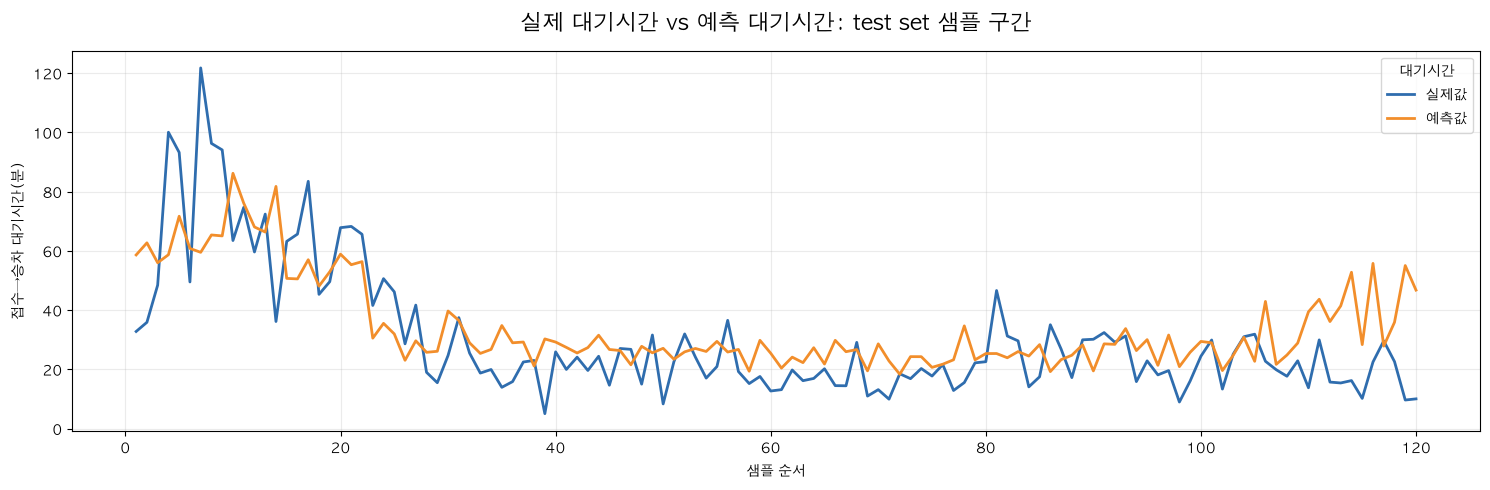

In [64]:
# =========================
# 33-2. 샘플 구간 실제값 vs 예측값 선그래프
# =========================

SAMPLE_START = 0
SAMPLE_SIZE = 120

plot_sample = presentation_pred_df.iloc[SAMPLE_START:SAMPLE_START + SAMPLE_SIZE].copy()

plt.figure(figsize=(15, 5))
plt.plot(
    plot_sample["sample_order"],
    plot_sample[PRESENTATION_ACTUAL_COL],
    label="실제값",
    linewidth=2,
    color="#2F6DAE",
)
plt.plot(
    plot_sample["sample_order"],
    plot_sample[PRESENTATION_PRED_COL],
    label="예측값",
    linewidth=2,
    color="#F28E2B",
)
plt.title("실제 대기시간 vs 예측 대기시간: test set 샘플 구간", fontsize=16, pad=15)
plt.xlabel("샘플 순서")
plt.ylabel("접수→승차 대기시간(분)")
plt.legend(title="대기시간")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 33-3. 분위수 구간 평균 실제값 vs 예측값

개별 호출 단위 예측은 변동성이 크기 때문에, 실제값을 분위수 구간으로 나누어 각 구간의 평균 실제값과 평균 예측값을 비교한다.

이 그래프는 모델이 낮은 대기시간 구간과 높은 대기시간 구간을 전반적으로 구분하는지 보기 좋다.

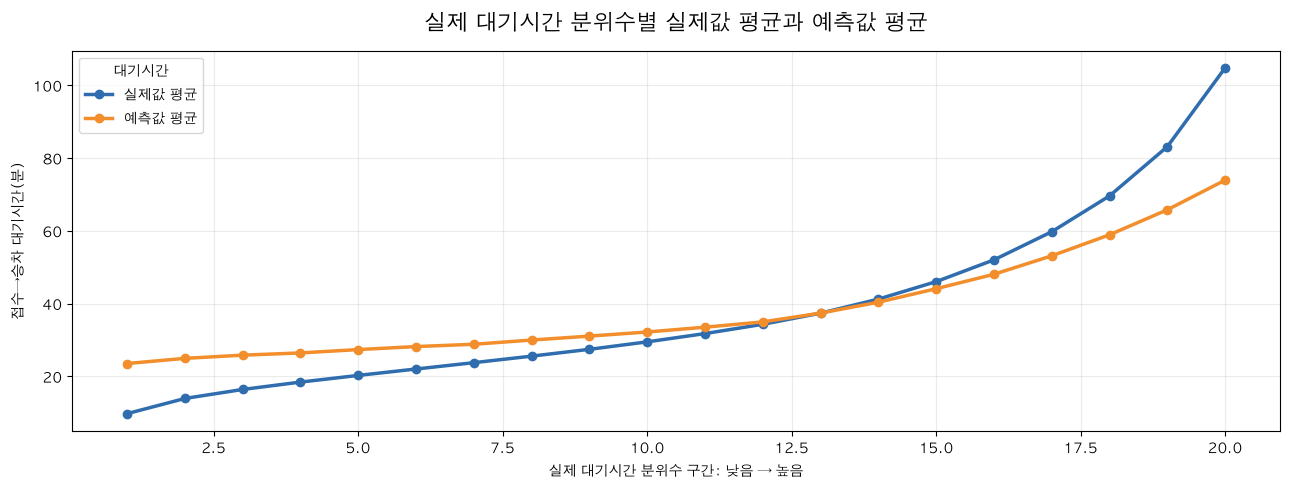

,실제값_평균,예측값_평균,건수,구간
0,9.76,23.54,9702,1
1,13.94,24.96,9701,2
2,16.41,25.84,9701,3
3,18.44,26.45,9701,4
4,20.27,27.37,9701,5
5,22.03,28.20,9701,6
6,23.77,28.83,9702,7
7,25.57,29.99,9700,8
8,27.44,31.07,9701,9
9,29.49,32.20,9701,10


In [65]:
# =========================
# 33-3. 분위수 구간 평균 실제값 vs 예측값
# =========================

N_BINS = 20

binned_plot_df = presentation_pred_df.copy()
binned_plot_df["actual_bin"] = pd.qcut(
    binned_plot_df[PRESENTATION_ACTUAL_COL],
    q=N_BINS,
    duplicates="drop",
)

bin_summary = (
    binned_plot_df
    .groupby("actual_bin", observed=True)
    .agg(
        실제값_평균=(PRESENTATION_ACTUAL_COL, "mean"),
        예측값_평균=(PRESENTATION_PRED_COL, "mean"),
        건수=(PRESENTATION_ACTUAL_COL, "size"),
    )
    .reset_index(drop=True)
)
bin_summary["구간"] = np.arange(1, len(bin_summary) + 1)

plt.figure(figsize=(13, 5))
plt.plot(
    bin_summary["구간"],
    bin_summary["실제값_평균"],
    marker="o",
    linewidth=2.5,
    label="실제값 평균",
    color="#2F6DAE",
)
plt.plot(
    bin_summary["구간"],
    bin_summary["예측값_평균"],
    marker="o",
    linewidth=2.5,
    label="예측값 평균",
    color="#F28E2B",
)
plt.title("실제 대기시간 분위수별 실제값 평균과 예측값 평균", fontsize=16, pad=15)
plt.xlabel("실제 대기시간 분위수 구간: 낮음 → 높음")
plt.ylabel("접수→승차 대기시간(분)")
plt.legend(title="대기시간")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(bin_summary.round(2))

### 33-4. 실제값-예측값 산점도

대각선에 가까울수록 실제값과 예측값이 비슷하다는 의미다.

전체 test set을 모두 그리면 점이 너무 많으므로, 발표용으로 일부 샘플만 사용한다.

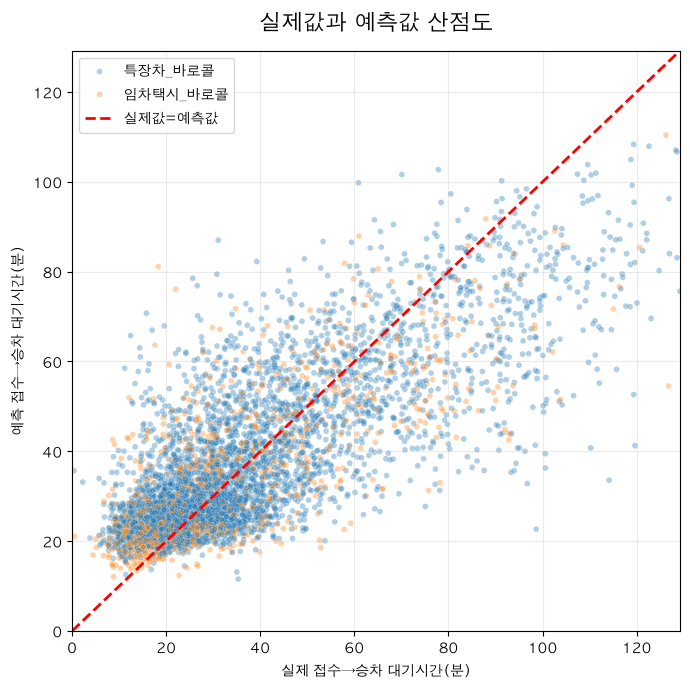

In [66]:
# =========================
# 33-4. 실제값-예측값 산점도
# =========================

SCATTER_SAMPLE_SIZE = 5000
scatter_sample = presentation_pred_df.sample(
    n=min(SCATTER_SAMPLE_SIZE, len(presentation_pred_df)),
    random_state=RANDOM_STATE,
)

max_axis = max(
    scatter_sample[PRESENTATION_ACTUAL_COL].max(),
    scatter_sample[PRESENTATION_PRED_COL].max(),
)

plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=scatter_sample,
    x=PRESENTATION_ACTUAL_COL,
    y=PRESENTATION_PRED_COL,
    hue="model_group",
    alpha=0.35,
    s=18,
)
plt.plot([0, max_axis], [0, max_axis], linestyle="--", color="red", linewidth=2, label="실제값=예측값")
plt.title("실제값과 예측값 산점도", fontsize=16, pad=15)
plt.xlabel("실제 접수→승차 대기시간(분)")
plt.ylabel("예측 접수→승차 대기시간(분)")
plt.xlim(0, max_axis)
plt.ylim(0, max_axis)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 34. 시각화 해석 메모

발표에서는 다음처럼 해석한다.

- 샘플 선그래프는 개별 호출 단위에서 실제값과 예측값의 움직임을 직관적으로 보여준다.
- 분위수 구간 평균 그래프는 낮은 대기시간 구간과 높은 대기시간 구간을 모델이 전반적으로 구분하는지 보여준다.
- 산점도는 개별 호출 예측의 오차 분포를 보여준다.
- 개별 호출 단위 예측은 일별 평균 예측보다 변동성이 크므로, 그래프가 완전히 겹치지 않는 것이 자연스럽다.